In [42]:
import re
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as ticker

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/DATASETS_For the data analysis/annual-enterprise-survey-2024-financial-year-provisional.csv") # read the csv file

print(f"Shape{df.shape}")
print(f"\nHead:\n{df.head()}\n")
print(f"\nTail:{df.tail()}\n")
print(f"\nColumn Names:\n{df.columns}\n")
print(f"\n{df.dtypes}\n")




In [25]:
print(f"\n{df.dtypes}\n")
print(f"\nMissing  Values:\n{df.isna().sum()}")
print(f"\nThere are {df.duplicated().sum()} number of duplicate rows in the dataset.\n")


# Remove irrelevant columns

for feature in df.columns:
  if df[feature].isna().sum().mean() >= 0.5:
    df = df.drop(columns=[feature])


# handling the missing values

if df.isna().sum().sum() > 0:
  df = df.apply(
    lambda cols: cols.fillna(cols.mean()) if np.issubdtype(cols.dtype, np.number)
    else cols.fillna(cols.mode()[0])
)

#  Remove duplicates

if df.duplicated().sum() > 0:
  df = df.drop_duplicates()

# fixing the datatype
df['Units'] = df['Units'].astype(str)
df['Industry_aggregation_NZSIOC'] = df['Industry_aggregation_NZSIOC'].astype('object')
df['Industry_name_NZSIOC'] = df['Industry_name_NZSIOC'].astype('object')
df['Industry_code_NZSIOC'] = df['Industry_code_NZSIOC'].astype('object')
df['Industry_code_ANZSIC06'] = df['Industry_code_ANZSIC06'].astype('object')
df['Variable_category'] = df['Variable_category'].astype('object')
df['Variable_code'] = df['Variable_code'].astype('object')
df['Variable_name'] = df['Variable_name'].astype('object')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')


Year                             int64
Industry_aggregation_NZSIOC     object
Industry_code_NZSIOC            object
Industry_name_NZSIOC            object
Units                           object
Variable_code                   object
Variable_name                   object
Variable_category               object
Value                          float64
Industry_code_ANZSIC06          object
dtype: object


Missing  Values:
Year                           0
Industry_aggregation_NZSIOC    0
Industry_code_NZSIOC           0
Industry_name_NZSIOC           0
Units                          0
Variable_code                  0
Variable_name                  0
Variable_category              0
Value                          0
Industry_code_ANZSIC06         0
dtype: int64

There are 0 number of duplicate rows in the dataset.



In [35]:
#  Clean text data
cat_cols = df.select_dtypes(exclude=[np.number]).columns # categorical columns
num_cols = df.drop(columns=['Year']).select_dtypes(include=[np.number]).columns # numeric columns

for feature in cat_cols:
  df[feature] = df[feature].str.lower().str.strip()


#  Univariate Analysis (Single Column)

#  distribution, skewness, spread

print(f"\nNumerical Features:\n")

for feature in num_cols:
  skew = df[feature].skew()
  if skew > 0.5:
    distribution = 'Right Skewed'
  elif skew < -0.5:
    distribution = 'Left Skewed'
  else:
    distribution = 'Approximately Normal'


  cv = df[feature].std() / df[feature].mean() if df[feature].mean() != 0 else 0

  if cv > 1:
    spread = 'High Variability'
  elif cv > 0.5:
    spread = 'Medium Variability'
  else:
    spread = 'Low Variability'


  print(f"{feature}: {distribution}: {spread}")


print(f"\nCategorical Features:\n")

for feature in cat_cols:
  print(f"\n{feature}:\n{df[feature].value_counts()}\n")




Numerical Features:

Value: Right Skewed: High Variability

Categorical Features:


Industry_aggregation_NZSIOC:
Industry_aggregation_NZSIOC
level 4    30444
level 3    18468
level 1     6708
Name: count, dtype: int64


Industry_code_NZSIOC:
Industry_code_NZSIOC
cc41     432
cc321    432
cc32     432
cc211    432
cc212    432
        ... 
kk121    300
kk131    300
kk122    300
kk13     300
kk12     300
Name: count, Length: 139, dtype: int64


Industry_name_NZSIOC:
Industry_name_NZSIOC
public order, safety and regulatory services             1116
pulp, paper and converted paper product manufacturing     864
wood product manufacturing                                864
petroleum and coal product manufacturing                  864
printing                                                  864
                                                         ... 
residential care services and social assistance           360
hospitals                                                 360
health and ge

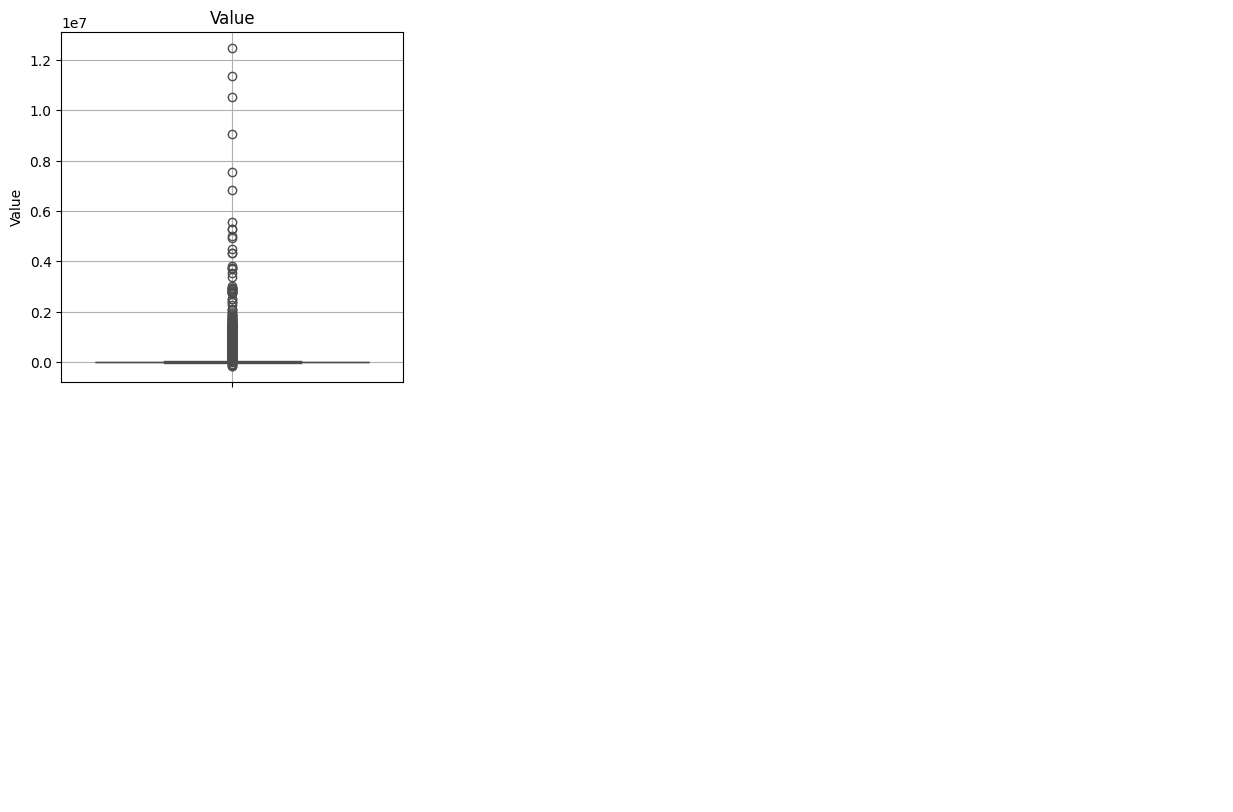

In [37]:
# Outlier Analysis

# box plot

cols = 3
rows = (len(df.columns) - cols + 1) // cols

fig1, ax1 = plt.subplots(rows, cols, figsize=(15, 5 * rows))
ax1 = ax1.flatten()

for i, feature in enumerate(num_cols):
  sns.boxplot(df[feature], ax=ax1[i], color='red')
  ax1[i].set_title(f"{feature}")
  ax1[i].grid(True)

for i in range(len(num_cols), len(ax1)):
  ax1[i].axis('off')



Correlation Can't be performed.


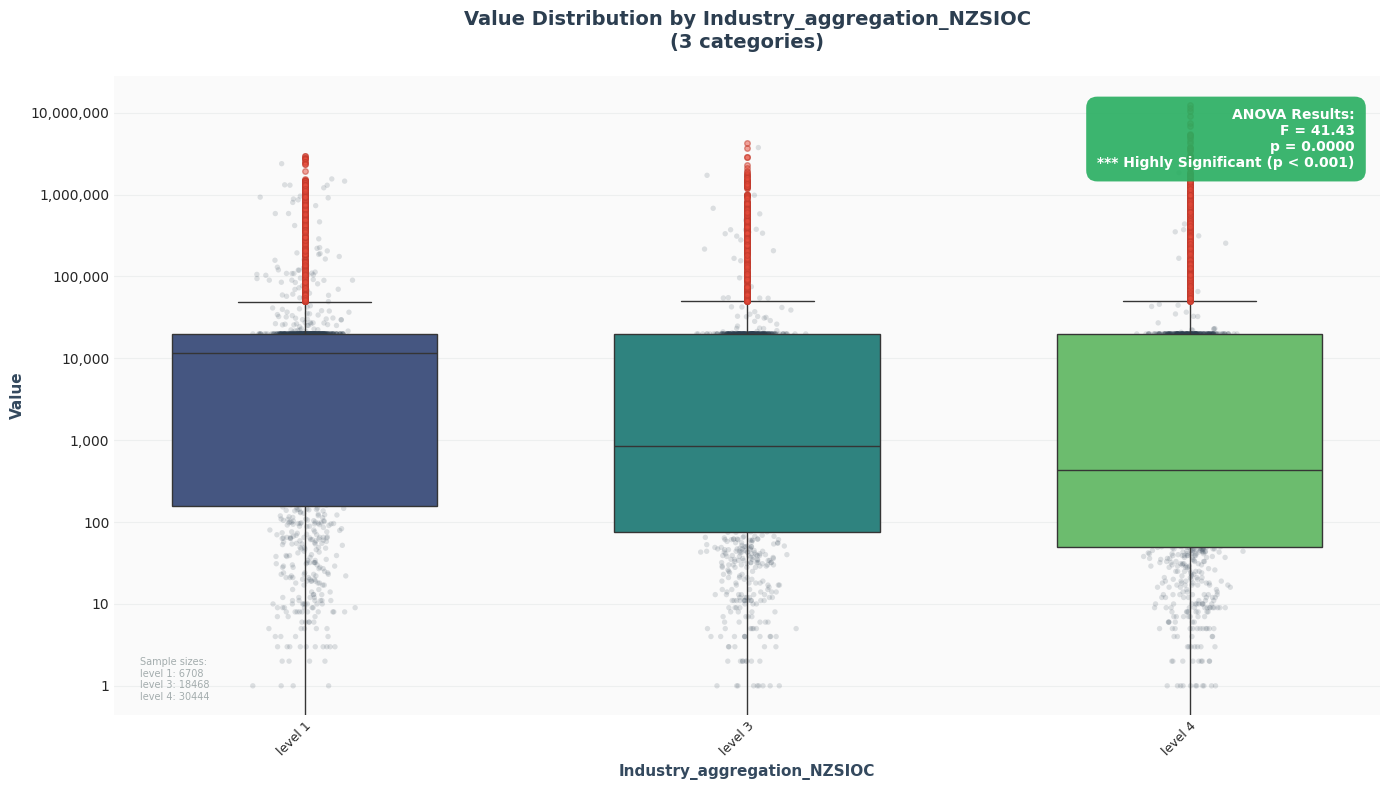


[Analysis] Value vs Industry_aggregation_NZSIOC
- F-statistic: 41.4268
- P-value: 0.0000
- Categories analyzed: 3
- Log scale used: Yes
- Group statistics:
                               count      mean        std       min    25%  \
Industry_aggregation_NZSIOC                                                  
level 1                       6708.0  36414.20  164740.26       0.0  159.0   
level 3                      18468.0  17744.96  101552.80 -152300.0   76.0   
level 4                      30444.0  17490.31  184092.30 -152300.0   50.0   

                                 50%       75%         max  
Industry_aggregation_NZSIOC                                 
level 1                      11747.0  19857.16   2931807.0  
level 3                        847.5  19857.16   4322700.0  
level 4                        430.0  19857.16  12475400.0  



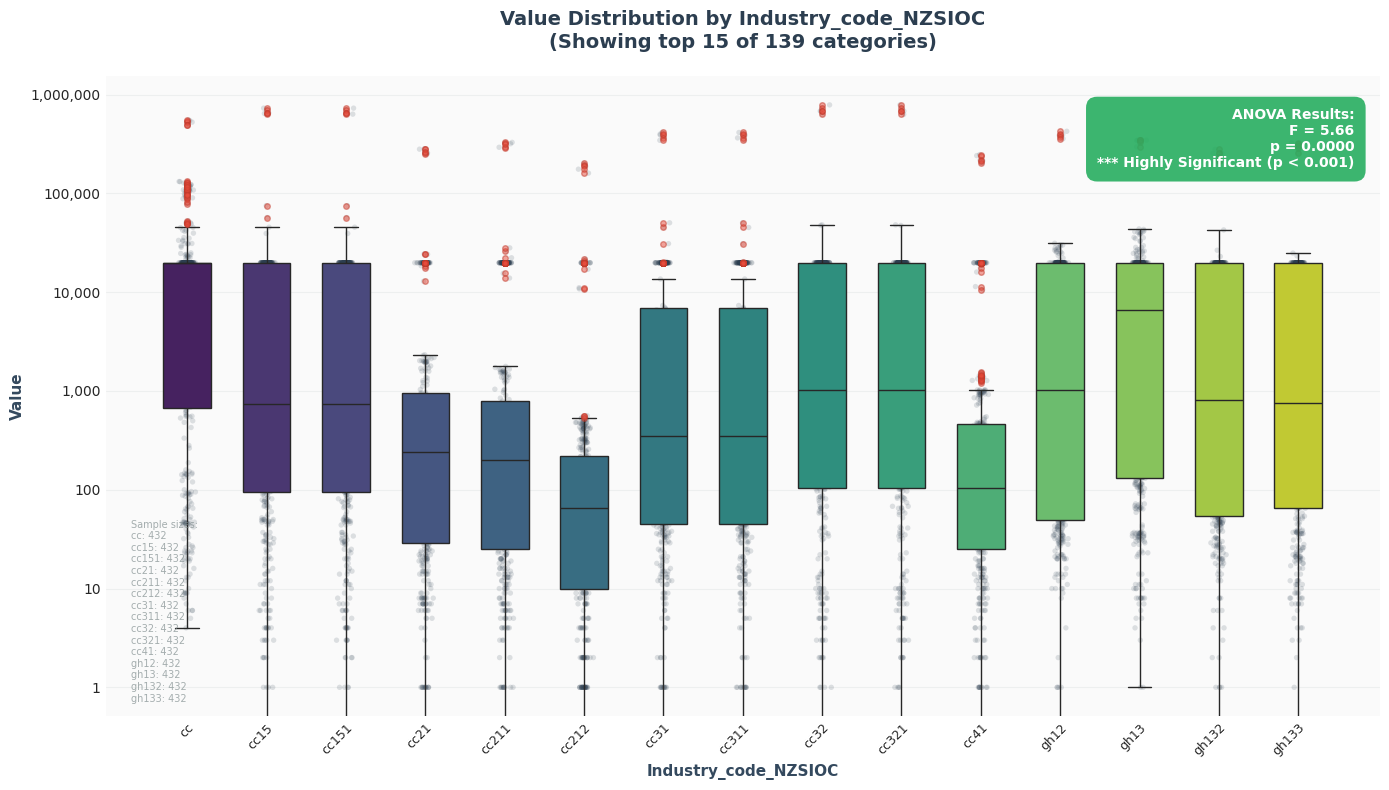


[Analysis] Value vs Industry_code_NZSIOC
- F-statistic: 5.6622
- P-value: 0.0000
- Categories analyzed: 139
- Log scale used: Yes
- Group statistics:
                      count      mean       std      min     25%       50%  \
Industry_code_NZSIOC                                                         
cc                    432.0  25687.03  60401.26      4.0  666.25  19857.16   
cc15                  432.0  15308.51  72008.52      0.0   94.75    737.50   
cc151                 432.0  15308.51  72008.52      0.0   94.75    737.50   
cc21                  432.0   6541.72  29150.38      0.0   28.75    241.00   
cc211                 432.0   7096.48  33742.42      0.0   25.00    198.00   
cc212                 432.0   3165.44  20075.70      0.0   10.00     66.00   
cc31                  432.0   9828.72  41352.02      0.0   45.00    348.50   
cc311                 432.0   9828.72  41352.02      0.0   45.00    348.50   
cc32                  432.0  15943.23  75143.09 -57700.0  104.75   10

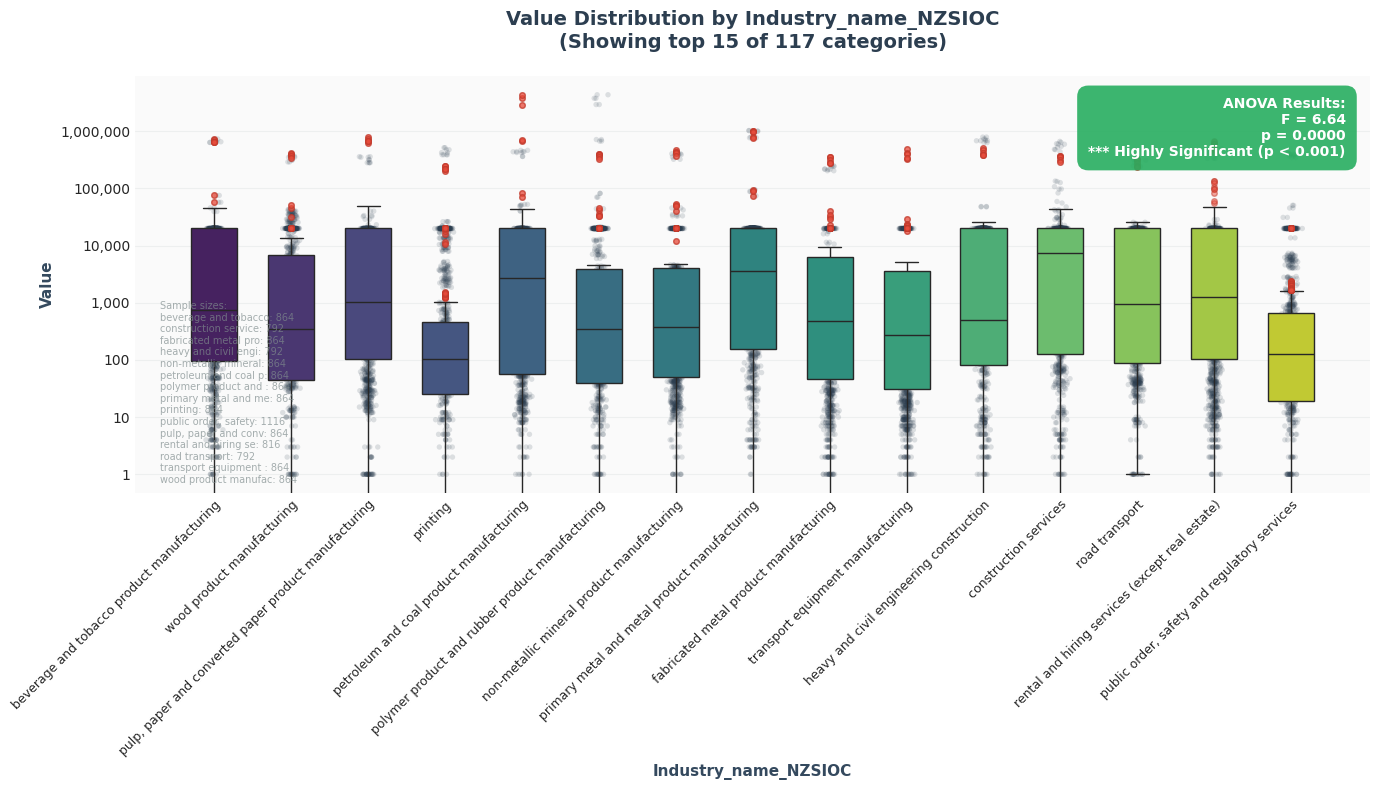


[Analysis] Value vs Industry_name_NZSIOC
- F-statistic: 6.6366
- P-value: 0.0000
- Categories analyzed: 117
- Log scale used: Yes
- Group statistics:
                                                     count      mean  \
Industry_name_NZSIOC                                                   
beverage and tobacco product manufacturing           864.0  15308.51   
construction services                                792.0  14864.53   
fabricated metal product manufacturing               864.0   8613.77   
heavy and civil engineering construction             792.0  12197.60   
non-metallic mineral product manufacturing           864.0   9897.13   
petroleum and coal product manufacturing             864.0  37547.48   
polymer product and rubber product manufacturing     864.0   9036.21   
primary metal and metal product manufacturing        864.0  20333.45   
printing                                             864.0   4909.65   
public order, safety and regulatory services        1116.

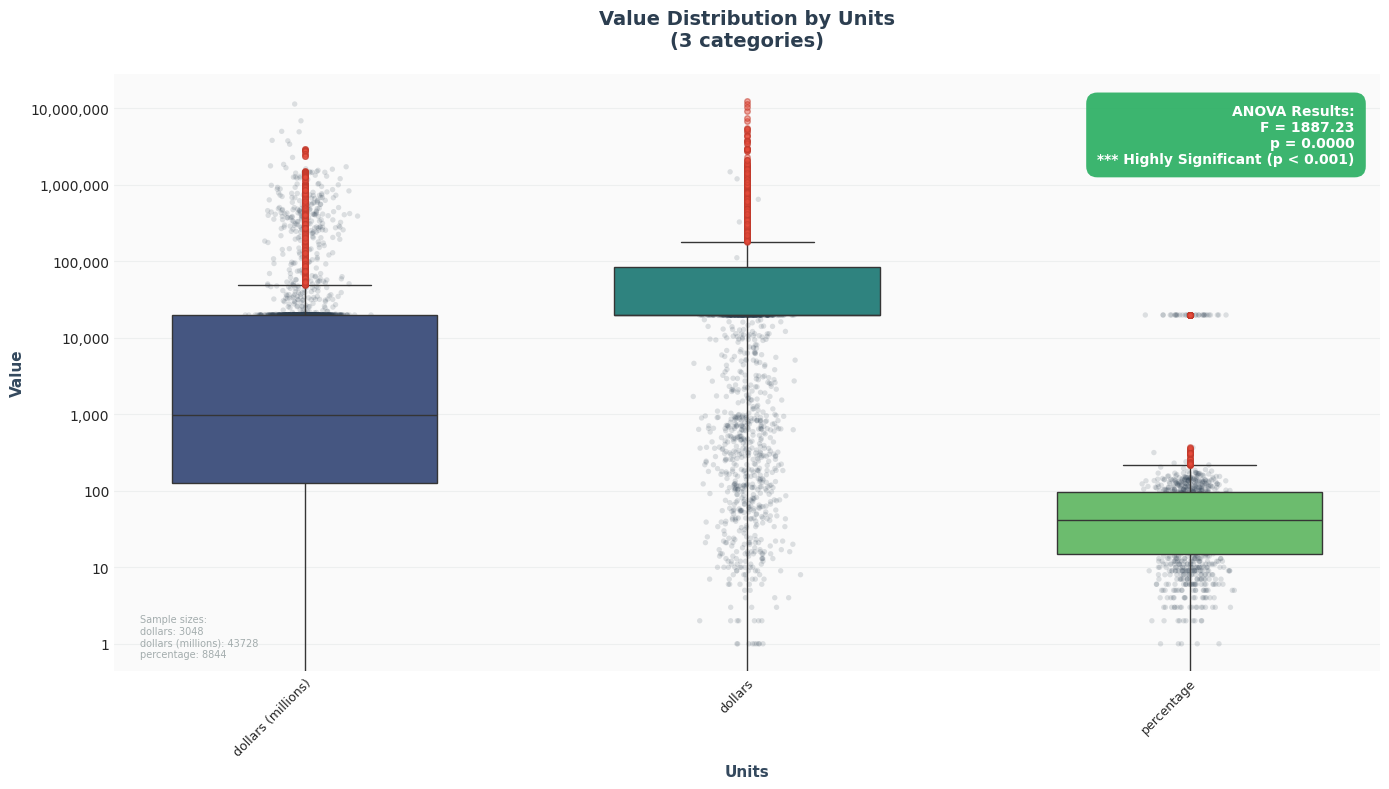


[Analysis] Value vs Units
- F-statistic: 1887.2286
- P-value: 0.0000
- Categories analyzed: 3
- Log scale used: Yes
- Group statistics:
                      count       mean        std       min       25%  \
Units                                                                   
dollars              3048.0  185455.18  607946.97 -152300.0  19857.16   
dollars (millions)  43728.0   12159.45   66022.19    -810.0    125.00   
percentage           8844.0     845.72    3876.87     -50.0     15.00   

                         50%       75%          max  
Units                                                
dollars             19857.16  83575.00  12475400.00  
dollars (millions)    989.00  19857.16   2931807.00  
percentage             42.00     95.00     19857.16  



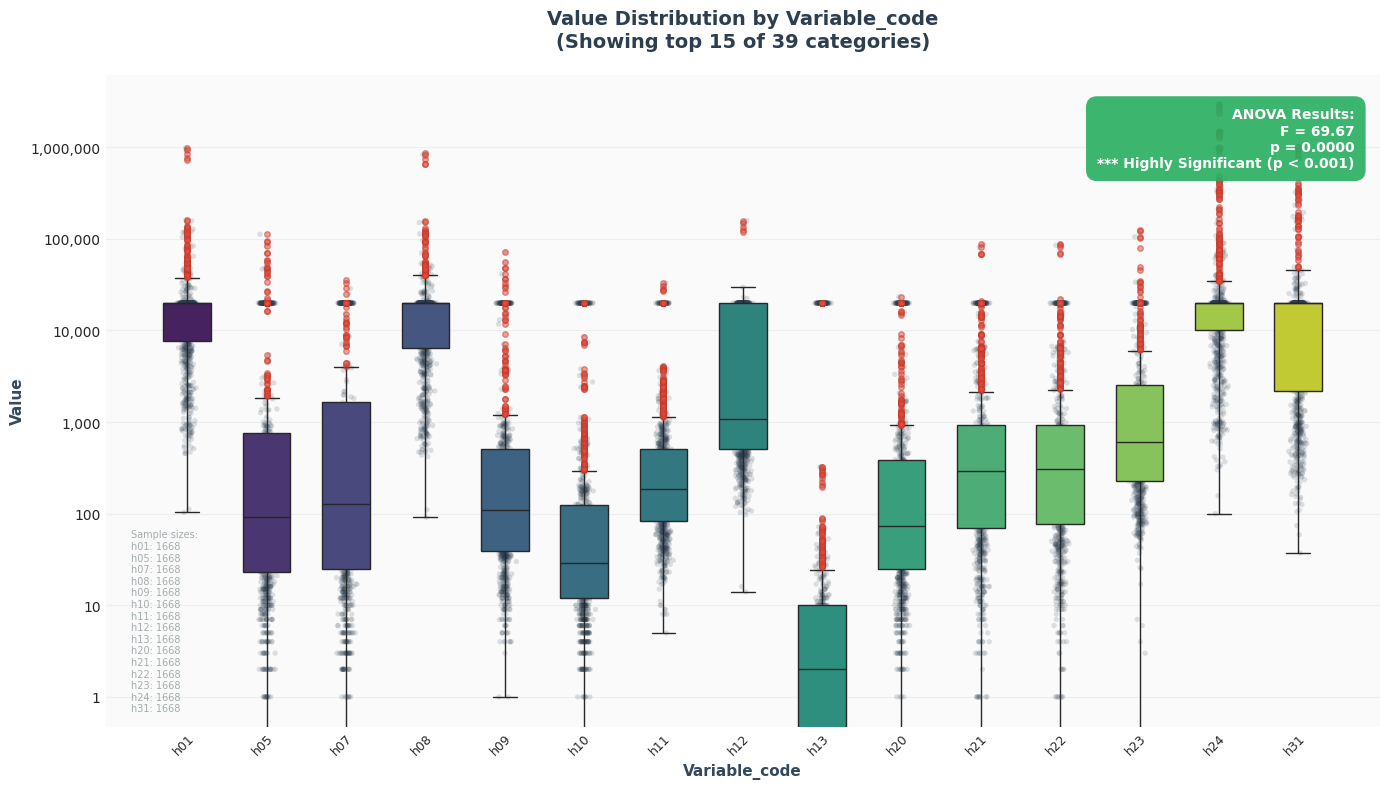


[Analysis] Value vs Variable_code
- F-statistic: 69.6713
- P-value: 0.0000
- Categories analyzed: 39
- Log scale used: Yes
- Group statistics:
                count      mean        std    min       25%       50%  \
Variable_code                                                           
h01            1668.0  20125.10   48352.60  103.0   7760.00  19857.16   
h05            1668.0   4544.66    9895.12    0.0     23.00     93.00   
h07            1668.0   4743.09    8267.77    0.0     25.00    128.50   
h08            1668.0  18733.54   42622.74   91.0   6489.00  19857.16   
h09            1668.0   3061.02    7342.95    1.0     39.00    109.00   
h10            1668.0   1871.50    5615.33    0.0     12.00     29.00   
h11            1668.0   1688.81    5021.56    5.0     83.00    184.50   
h12            1668.0   7066.86   11111.86   14.0    502.50   1082.00   
h13            1668.0   2530.09    6613.72    0.0      0.00      2.00   
h20            1668.0   2809.73    6655.82    0.0    

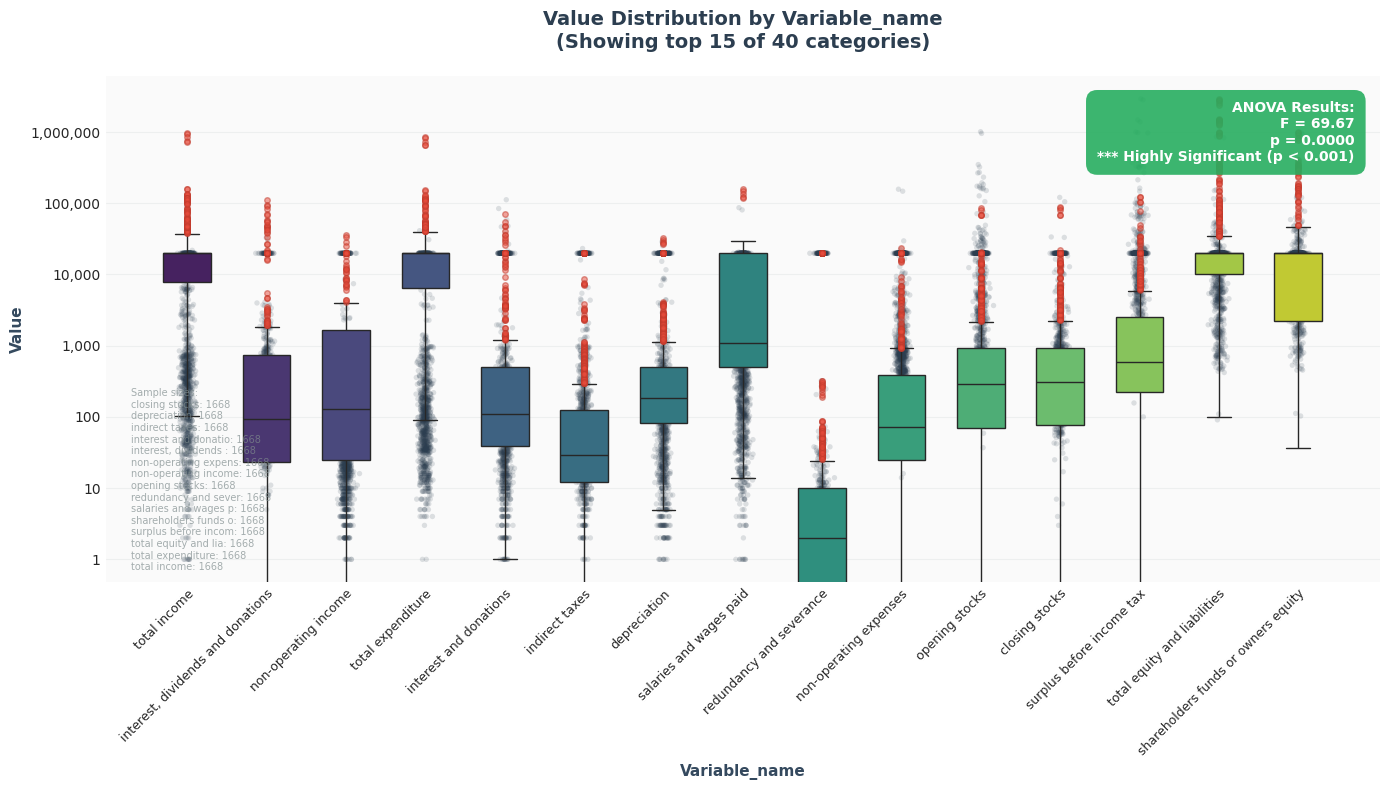


[Analysis] Value vs Variable_name
- F-statistic: 69.6713
- P-value: 0.0000
- Categories analyzed: 40
- Log scale used: Yes
- Group statistics:
                                      count      mean        std    min  \
Variable_name                                                             
closing stocks                       1668.0   3701.16    8023.86    0.0   
depreciation                         1668.0   1688.81    5021.56    5.0   
indirect taxes                       1668.0   1871.50    5615.33    0.0   
interest and donations               1668.0   3061.02    7342.95    1.0   
interest, dividends and donations    1668.0   4544.66    9895.12    0.0   
non-operating expenses               1668.0   2809.73    6655.82    0.0   
non-operating income                 1668.0   4743.09    8267.77    0.0   
opening stocks                       1668.0   3622.63    7877.71    0.0   
redundancy and severance             1668.0   2530.09    6613.72    0.0   
salaries and wages paid        

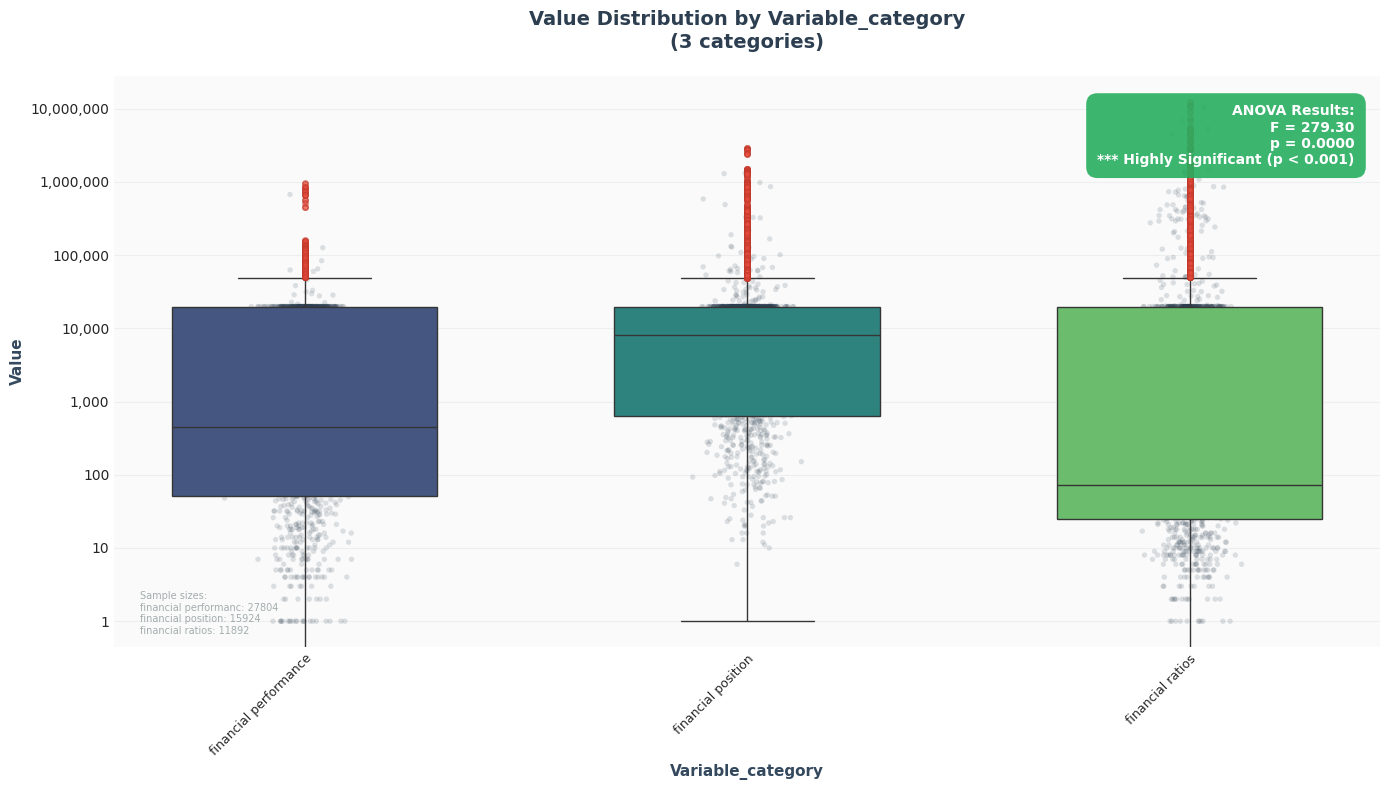


[Analysis] Value vs Variable_category
- F-statistic: 279.3025
- P-value: 0.0000
- Categories analyzed: 3
- Log scale used: Yes
- Group statistics:
                         count      mean        std       min     25%     50%  \
Variable_category                                                               
financial performance  27804.0   7216.97   22323.07    -810.0   51.00   452.0   
financial position     15924.0  20789.24  104800.02       1.0  626.75  8014.0   
financial ratios       11892.0  48162.37  318144.15 -152300.0   25.00    72.0   

                            75%         max  
Variable_category                            
financial performance  19857.16    979594.0  
financial position     19857.16   2931807.0  
financial ratios       19857.16  12475400.0  



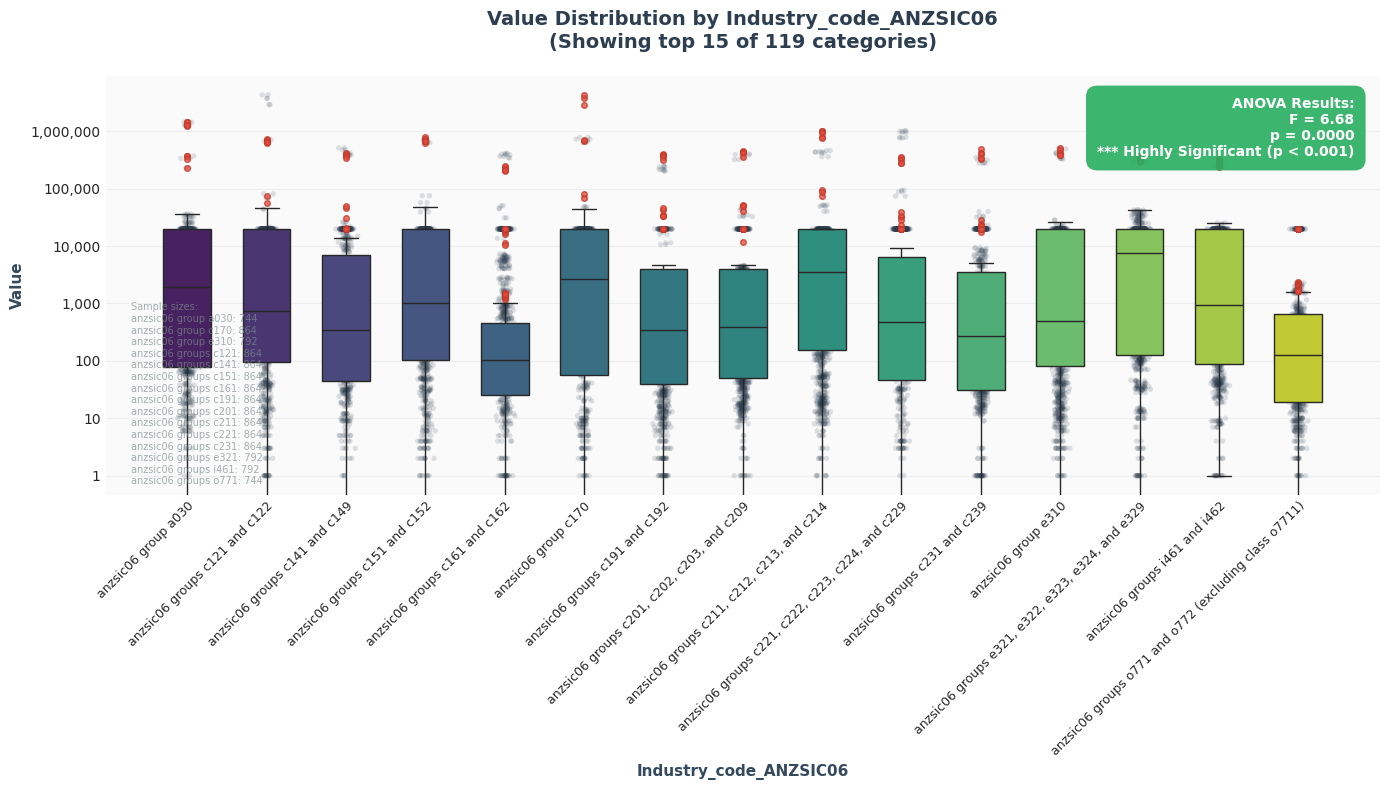


[Analysis] Value vs Industry_code_ANZSIC06
- F-statistic: 6.6836
- P-value: 0.0000
- Categories analyzed: 119
- Log scale used: Yes
- Group statistics:
                                                    count      mean  \
Industry_code_ANZSIC06                                                
anzsic06 group a030                                 744.0  29838.52   
anzsic06 group c170                                 864.0  37547.48   
anzsic06 group e310                                 792.0  12197.60   
anzsic06 groups c121 and c122                       864.0  15308.51   
anzsic06 groups c141 and c149                       864.0   9828.72   
anzsic06 groups c151 and c152                       864.0  15943.23   
anzsic06 groups c161 and c162                       864.0   4909.65   
anzsic06 groups c191 and c192                       864.0   9036.21   
anzsic06 groups c201, c202, c203, and c209          864.0   9897.13   
anzsic06 groups c211, c212, c213, and c214          864.0  20333.4

In [43]:
#  Bivariate Analysis (Relationships)

#  Numeric vs Numeric → correlation patterns

if len(num_cols) == 1:
  print(f"Correlation Can't be performed.")
else:
  corr = df[num_cols].corr() # correlation
  print(corr)


# Fix for missing glyphs - use text instead of emoji
plt.rcParams['font.family'] = 'DejaVu Sans'

def analyze_numeric_vs_categorical_pro(df, num_cols, cat_cols, max_categories=15):
    """
    Professional Numeric vs Categorical Analysis
    Auto-detects if log scale is needed
    """

    for num_col in num_cols:
        for cat_col in cat_cols:

            # Check if category has too many unique values
            n_categories = df[cat_col].nunique()
            if n_categories > max_categories:
                # For many categories, show top N by count
                top_cats = df[cat_col].value_counts().nlargest(max_categories).index
                df_plot = df[df[cat_col].isin(top_cats)].copy()
                subtitle = f"(Showing top {max_categories} of {n_categories} categories)"
            else:
                df_plot = df.copy()
                subtitle = f"({n_categories} categories)"

            # Calculate statistics
            groups = [group[num_col].dropna().values
                     for name, group in df_plot.groupby(cat_col)]
            f_stat, p_value = stats.f_oneway(*groups)

            # Determine if log scale is needed
            data_range = df_plot[num_col].max() / max(df_plot[num_col].min(), 1)
            use_log = data_range > 100

            # Create professional figure
            fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
            ax.set_facecolor('#fafafa')

            # FIXED: Use hue instead of palette for seaborn boxplot
            bp = sns.boxplot(
                data=df_plot,
                x=cat_col,
                y=num_col,
                hue=cat_col,  # Assign x variable to hue
                legend=False,  # Set legend=False
                width=0.6,
                flierprops=dict(
                    marker='o',
                    markerfacecolor='#e74c3c',
                    markersize=4,
                    alpha=0.5,
                    markeredgecolor='#c0392b'
                ),
                palette='viridis',  # Now we can use palette with hue
                ax=ax
            )

            # Add individual points with jitter (sample if too many)
            for i, (name, group) in enumerate(df_plot.groupby(cat_col)):
                y_data = group[num_col].dropna()
                # Sample if more than 1000 points
                if len(y_data) > 1000:
                    y_data = y_data.sample(1000, random_state=42)

                # Add jittered points
                jitter = np.random.normal(0, 0.04, size=len(y_data))
                ax.scatter(
                    np.ones(len(y_data)) * i + jitter,
                    y_data,
                    alpha=0.15,
                    s=15,
                    color='#2c3e50',
                    edgecolors='none',
                    zorder=1
                )

            # Apply log scale if needed
            if use_log:
                ax.set_yscale('log')
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(
                    lambda x, p: f'{x:,.0f}' if x >= 1 else f'{x:.2f}'
                ))
            else:
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(
                    lambda x, p: f'{x:,.0f}'
                ))

            # Enhanced styling
            ax.set_title(
                f'{num_col} Distribution by {cat_col}\n'
                f'{subtitle}',
                fontsize=14,
                fontweight='bold',
                color='#2c3e50',
                pad=20
            )

            ax.set_xlabel(cat_col, fontsize=11, fontweight='bold', color='#34495e')
            ax.set_ylabel(num_col, fontsize=11, fontweight='bold', color='#34495e')

            # Rotate x-labels with better alignment
            plt.setp(ax.get_xticklabels(),
                    rotation=45,
                    ha='right',
                    rotation_mode='anchor',
                    fontsize=9)

            # Professional grid
            ax.grid(True, alpha=0.2, linestyle='-', color='#bdc3c7', axis='y')
            ax.set_axisbelow(True)

            # Remove top and right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('#cccccc')
            ax.spines['bottom'].set_color('#cccccc')

            # FIXED: Use text symbols instead of emoji
            if p_value < 0.001:
                significance = "*** Highly Significant (p < 0.001)"
                box_color = '#27ae60'
                text_color = 'white'
            elif p_value < 0.01:
                significance = "** Very Significant (p < 0.01)"
                box_color = '#2ecc71'
                text_color = 'white'
            elif p_value < 0.05:
                significance = "* Significant (p < 0.05)"
                box_color = '#f1c40f'
                text_color = '#2c3e50'
            else:
                significance = "NS (Not Significant)"
                box_color = '#e74c3c'
                text_color = 'white'

            ax.text(
                0.98, 0.95,
                f'ANOVA Results:\n'
                f'F = {f_stat:.2f}\n'
                f'p = {p_value:.4f}\n'
                f'{significance}',
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(
                    boxstyle='round,pad=0.8',
                    facecolor=box_color,
                    edgecolor='none',
                    alpha=0.9
                ),
                color=text_color,
                fontweight='bold'
            )

            # Add sample size per group
            sample_sizes = df_plot.groupby(cat_col).size()
            ax.text(
                0.02, 0.02,
                'Sample sizes:\n' + '\n'.join([
                    f'{name[:20]}: {size}'
                    for name, size in sample_sizes.items()
                ]),
                transform=ax.transAxes,
                fontsize=7,
                verticalalignment='bottom',
                color='#7f8c8d',
                alpha=0.7
            )

            plt.tight_layout()
            plt.show()

            # FIXED: Print summary without emoji
            print(f"\n{'='*70}")
            print(f"[Analysis] {num_col} vs {cat_col}")
            print(f"{'='*70}")
            print(f"- F-statistic: {f_stat:.4f}")
            print(f"- P-value: {p_value:.4f}")
            print(f"- Categories analyzed: {n_categories}")
            print(f"- Log scale used: {'Yes' if use_log else 'No'}")
            print(f"- Group statistics:")
            print(df_plot.groupby(cat_col)[num_col].describe().round(2))
            print(f"{'='*70}\n")

# Use it
analyze_numeric_vs_categorical_pro(df, num_cols, cat_cols)

CORRELATION MATRIX
       Value
Value    1.0


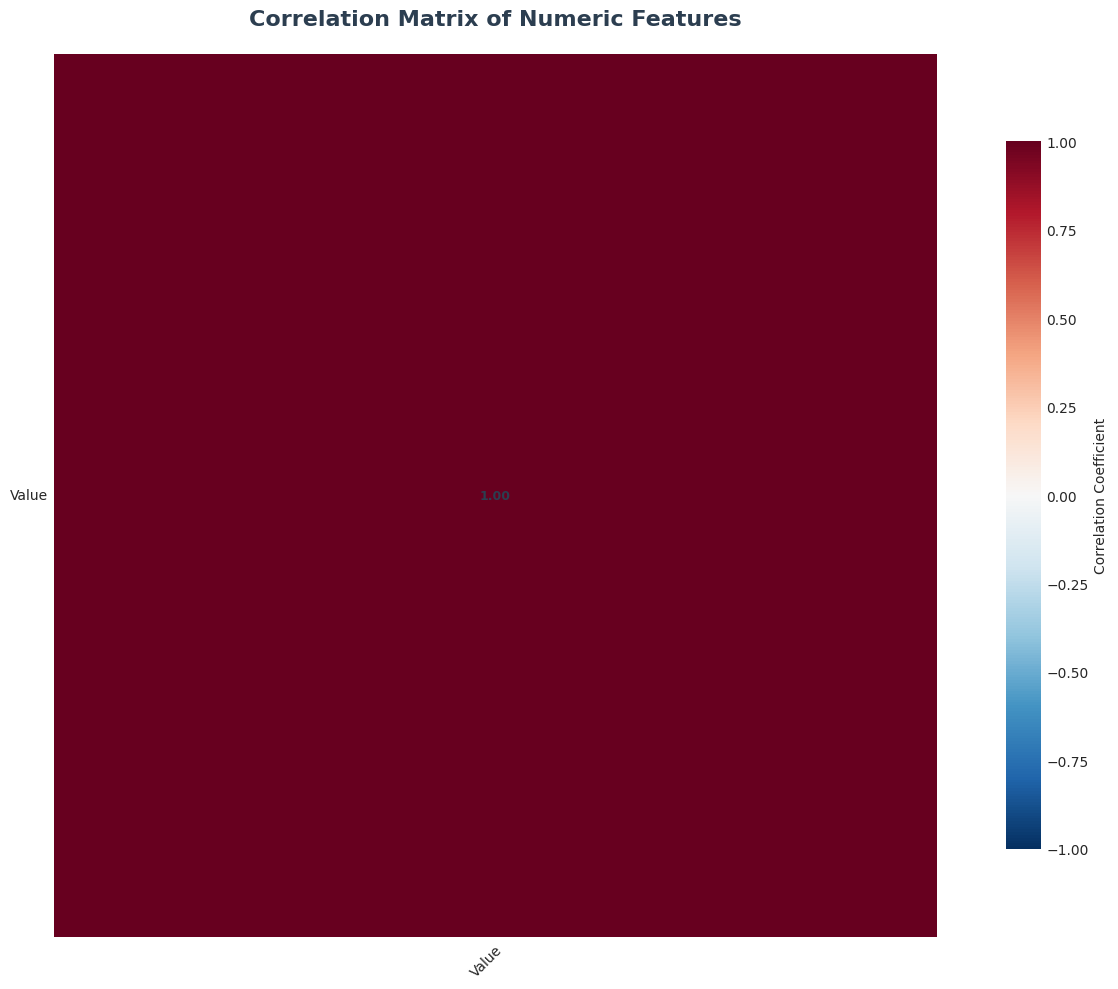


No strong correlations found above |r| = 0.7


In [44]:
#  Correlation Analysis

def correlation_analysis(df, num_cols, threshold=0.7):
    """
    Professional Correlation Analysis
    - Builds correlation matrix
    - Creates heatmap visualization
    - Identifies strong relationships
    """

    # ============================================
    # 1. BUILD CORRELATION MATRIX
    # ============================================
    corr_matrix = df[num_cols].corr()

    print("="*70)
    print("CORRELATION MATRIX")
    print("="*70)
    print(corr_matrix.round(3))

    # ============================================
    # 2. HEATMAP VISUALIZATION
    # ============================================
    fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    # Professional heatmap
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={
            'label': 'Correlation Coefficient',
            'shrink': 0.8,
            'aspect': 20
        },
        annot_kws={
            'size': 9,
            'weight': 'bold',
            'color': '#2c3e50'
        },
        ax=ax
    )

    # Enhanced styling
    ax.set_title(
        'Correlation Matrix of Numeric Features',
        fontsize=16,
        fontweight='bold',
        color='#2c3e50',
        pad=20
    )

    # Rotate labels
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha='right',
        rotation_mode='anchor',
        fontsize=10
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

    # ============================================
    # 3. IDENTIFY STRONG RELATIONSHIPS
    # ============================================

    # Find all strong correlations
    strong_corrs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) >= threshold:
                strong_corrs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_value,
                    'Abs_Correlation': abs(corr_value)
                })

    # Convert to DataFrame and sort
    if strong_corrs:
        strong_df = pd.DataFrame(strong_corrs)
        strong_df = strong_df.sort_values('Abs_Correlation', ascending=False)
        strong_df = strong_df.drop('Abs_Correlation', axis=1)

        print("\n" + "="*70)
        print(f"STRONG CORRELATIONS (|r| >= {threshold})")
        print("="*70)

        for idx, row in strong_df.iterrows():
            corr = row['Correlation']
            abs_corr = abs(corr)

            # Classify strength
            if abs_corr >= 0.9:
                strength = "Very Strong"
            elif abs_corr >= 0.8:
                strength = "Strong"
            elif abs_corr >= 0.7:
                strength = "Moderate-Strong"
            else:
                strength = "Moderate"

            # Determine direction
            direction = "Positive" if corr > 0 else "Negative"

            print(f"\n{row['Feature 1']} <-> {row['Feature 2']}")
            print(f"  Correlation: {corr:.3f} ({strength} {direction})")

            # Add recommendation
            if abs_corr > 0.9:
                print(f"  [WARNING] Near multicollinearity - consider removing one feature")
            elif abs_corr > 0.8:
                print(f"  [NOTE] Strong relationship - these features are highly dependent")
    else:
        print(f"\nNo strong correlations found above |r| = {threshold}")

    # ============================================
    # 4. FEATURE CLUSTERING (Optional but useful)
    # ============================================

    # Identify groups of correlated features
    if strong_corrs:
        print("\n" + "="*70)
        print("CORRELATED FEATURE GROUPS")
        print("="*70)

        # Create a set of all features involved in strong correlations
        correlated_features = set()
        for corr in strong_corrs:
            correlated_features.add(corr['Feature 1'])
            correlated_features.add(corr['Feature 2'])

        # Group correlated features
        groups = []
        visited = set()

        for feature in correlated_features:
            if feature not in visited:
                group = {feature}
                visited.add(feature)

                # Find all features strongly correlated with this one
                for corr in strong_corrs:
                    if corr['Feature 1'] == feature and corr['Feature 2'] not in visited:
                        group.add(corr['Feature 2'])
                        visited.add(corr['Feature 2'])
                    elif corr['Feature 2'] == feature and corr['Feature 1'] not in visited:
                        group.add(corr['Feature 1'])
                        visited.add(corr['Feature 1'])

                if len(group) > 1:
                    groups.append(group)

        for i, group in enumerate(groups, 1):
            print(f"\nGroup {i}: {', '.join(group)}")
            print(f"  -> Consider keeping only one feature from this group for modeling")

    return corr_matrix, strong_df if strong_corrs else None

# Use it
corr_matrix, strong_corrs = correlation_analysis(df, num_cols, threshold=0.7)

                    DATA STORY DASHBOARD
Dataset Shape: 55,620 rows × 10 columns
Numerical Features: 1
Categorical Features: 8


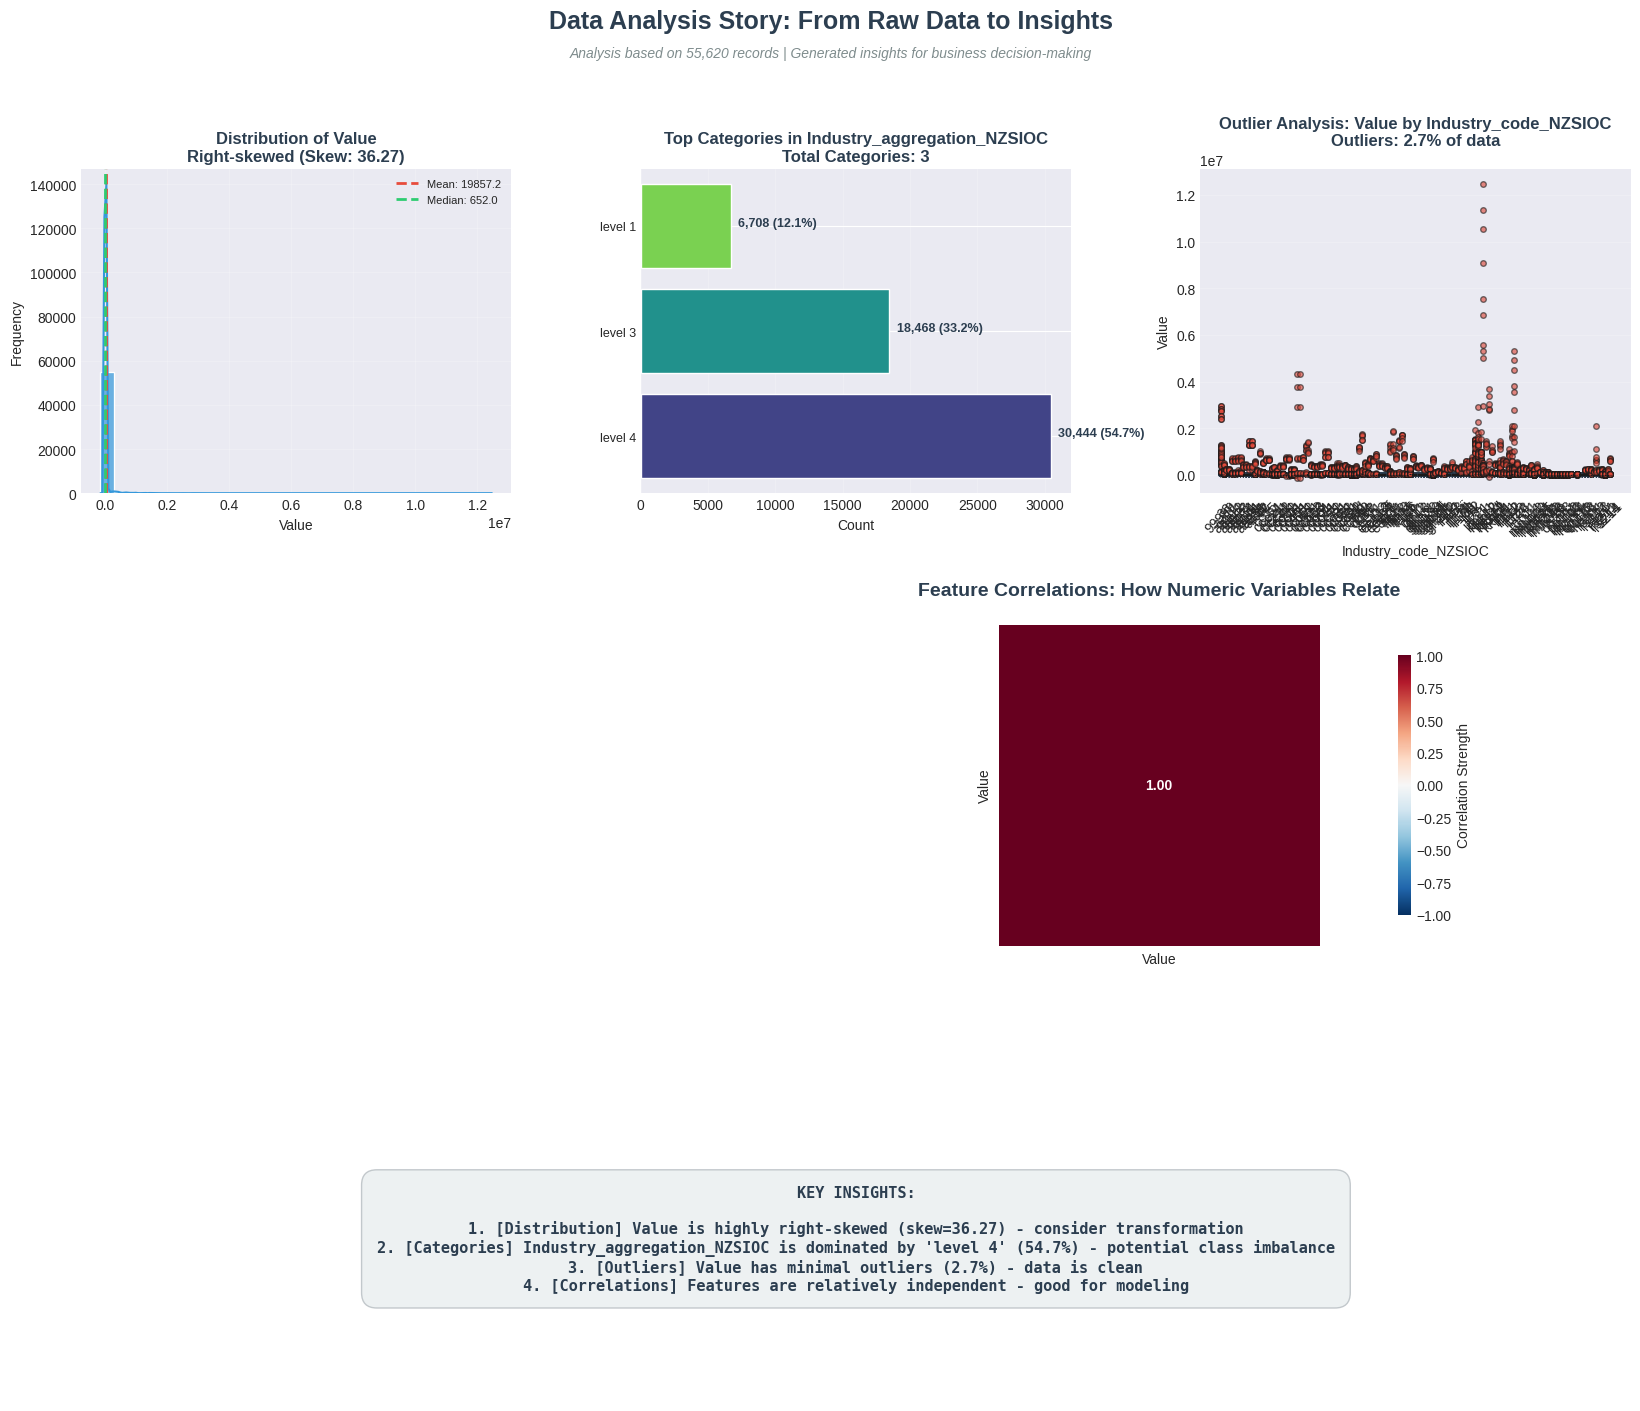


DETAILED STATISTICAL SUMMARY

[1] DISTRIBUTION ANALYSIS:
    • Feature: Value
    • Mean: 19857.16
    • Median: 652.00
    • Std Dev: 159009.82
    • Skewness: 36.27
    • Kurtosis: 2033.85

[2] CATEGORICAL ANALYSIS:
    • Feature: Industry_aggregation_NZSIOC
    • Unique Categories: 3
    • Most Common: level 4 (30,444 occurrences)
    • Least Common: level 1 (6,708 occurrences)

[3] OUTLIER ANALYSIS:
    • Feature: Value
    • Q1: 64.00
    • Q3: 19857.16
    • IQR: 19793.16
    • Lower Bound: -29625.74
    • Upper Bound: 49546.91
    • Outliers Detected: 1515 (2.7%)

[4] CORRELATION ANALYSIS:
    • Strongest Correlation:  (r=0.00)
    • Features with high correlation (>0.7):
      None found - features are independent

RECOMMENDATIONS BASED ON ANALYSIS:
1. Consider log transformation for highly skewed features
2. Address class imbalance in categorical variables before modeling
3. Investigate and handle outliers based on domain knowledge
4. Remove highly correlated features to avoi

In [45]:
# Data Visualization (Story Building)


# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def data_story_dashboard(df, num_cols, cat_cols, target_col=None):
    """
    Complete Data Story Dashboard
    Tells the story of your data through 4 key visualizations
    """

    # ============================================
    # STORY TITLE
    # ============================================
    print("="*80)
    print(" " * 20 + "DATA STORY DASHBOARD")
    print("="*80)
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Numerical Features: {len(num_cols)}")
    print(f"Categorical Features: {len(cat_cols)}")
    print("="*80)

    # ============================================
    # DASHBOARD LAYOUT
    # ============================================
    fig = plt.figure(figsize=(20, 16), facecolor='white')

    # Create grid for 4 visualizations + summary
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

    # ============================================
    # 1. HISTOGRAMS - Distribution Story
    # ============================================
    ax1 = fig.add_subplot(gs[0, 0])

    # Select first numeric column or most important one
    hist_col = num_cols[0]

    # Histogram with KDE
    sns.histplot(
        data=df,
        x=hist_col,
        kde=True,
        bins=30,
        color='#3498db',
        edgecolor='white',
        alpha=0.7,
        ax=ax1
    )

    # Add mean and median lines
    mean_val = df[hist_col].mean()
    median_val = df[hist_col].median()

    ax1.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Mean: {mean_val:.1f}')
    ax1.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=2,
                label=f'Median: {median_val:.1f}')

    # Calculate skewness
    skewness = df[hist_col].skew()
    skew_type = "Right-skewed" if skewness > 0.5 else "Left-skewed" if skewness < -0.5 else "Normal"

    ax1.set_title(f'Distribution of {hist_col}\n{skew_type} (Skew: {skewness:.2f})',
                  fontsize=12, fontweight='bold', color='#2c3e50')
    ax1.set_xlabel(hist_col, fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.2)

    # ============================================
    # 2. BAR CHARTS - Category Story
    # ============================================
    ax2 = fig.add_subplot(gs[0, 1])

    # Select first categorical column
    bar_col = cat_cols[0]

    # Count frequencies
    freq_data = df[bar_col].value_counts().head(10)

    # Horizontal bar chart
    bars = ax2.barh(
        range(len(freq_data)),
        freq_data.values,
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(freq_data))),
        edgecolor='white',
        linewidth=1
    )

    # Add percentage labels
    total = len(df)
    for i, (value, category) in enumerate(zip(freq_data.values, freq_data.index)):
        percentage = (value / total) * 100
        ax2.text(
            value + total*0.01, i,
            f'{value:,} ({percentage:.1f}%)',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50'
        )

    ax2.set_yticks(range(len(freq_data)))
    ax2.set_yticklabels([str(cat)[:20] for cat in freq_data.index], fontsize=9)
    ax2.set_xlabel('Count', fontsize=10)
    ax2.set_title(f'Top Categories in {bar_col}\nTotal Categories: {df[bar_col].nunique()}',
                  fontsize=12, fontweight='bold', color='#2c3e50')
    ax2.grid(True, alpha=0.2, axis='x')

    # ============================================
    # 3. BOX PLOTS - Outlier Story
    # ============================================
    ax3 = fig.add_subplot(gs[0, 2])

    # Box plot for numeric columns by category
    if target_col and target_col in cat_cols:
        box_x = target_col
    elif len(cat_cols) > 1:
        box_x = cat_cols[1]
    else:
        box_x = cat_cols[0]

    box_y = num_cols[0]

    # Create box plot
    bp = sns.boxplot(
        data=df,
        x=box_x,
        y=box_y,
        hue=box_x,
        legend=False,
        palette='viridis',
        width=0.6,
        flierprops=dict(
            marker='o',
            markerfacecolor='#e74c3c',
            markersize=4,
            alpha=0.6
        ),
        ax=ax3
    )

    # Add individual points
    for i, (name, group) in enumerate(df.groupby(box_x)):
        y_data = group[box_y].dropna()
        if len(y_data) > 500:
            y_data = y_data.sample(500, random_state=42)
        jitter = np.random.normal(0, 0.04, size=len(y_data))
        ax3.scatter(
            np.ones(len(y_data)) * i + jitter,
            y_data,
            alpha=0.1,
            s=10,
            color='#2c3e50',
            edgecolors='none'
        )

    # Calculate outlier percentage
    Q1 = df[box_y].quantile(0.25)
    Q3 = df[box_y].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(df[(df[box_y] < Q1 - 1.5*IQR) | (df[box_y] > Q3 + 1.5*IQR)])
    outlier_pct = (outlier_count / len(df)) * 100

    ax3.set_title(f'Outlier Analysis: {box_y} by {box_x}\nOutliers: {outlier_pct:.1f}% of data',
                  fontsize=12, fontweight='bold', color='#2c3e50')
    ax3.set_xlabel(box_x, fontsize=10)
    ax3.set_ylabel(box_y, fontsize=10)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.2, axis='y')

    # ============================================
    # 4. HEATMAP - Correlation Story
    # ============================================
    ax4 = fig.add_subplot(gs[1, :])  # Span full width

    # Calculate correlation matrix
    corr_matrix = df[num_cols].corr()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    # Professional heatmap
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=1,
        linecolor='white',
        cbar_kws={
            'label': 'Correlation Strength',
            'shrink': 0.8
        },
        annot_kws={
            'size': 10,
            'weight': 'bold'
        },
        ax=ax4
    )

    ax4.set_title('Feature Correlations: How Numeric Variables Relate',
                  fontsize=14, fontweight='bold', color='#2c3e50', pad=20)

    # ============================================
    # 5. STORY SUMMARY
    # ============================================
    ax5 = fig.add_subplot(gs[2, :])  # Span full width
    ax5.axis('off')

    # Generate insights
    insights = []

    # Distribution insight
    if abs(skewness) > 1:
        insights.append(f"[Distribution] {hist_col} is highly {skew_type.lower()} (skew={skewness:.2f}) - consider transformation")
    else:
        insights.append(f"[Distribution] {hist_col} shows {'slight' if abs(skewness) > 0.5 else 'minimal'} {skew_type.lower()} pattern")

    # Category insight
    top_cat_pct = (freq_data.iloc[0] / total) * 100
    if top_cat_pct > 50:
        insights.append(f"[Categories] {bar_col} is dominated by '{freq_data.index[0]}' ({top_cat_pct:.1f}%) - potential class imbalance")
    else:
        insights.append(f"[Categories] {bar_col} has balanced distribution with {df[bar_col].nunique()} unique categories")

    # Outlier insight
    if outlier_pct > 5:
        insights.append(f"[Outliers] {box_y} has {outlier_pct:.1f}% outliers - investigate extreme values")
    else:
        insights.append(f"[Outliers] {box_y} has minimal outliers ({outlier_pct:.1f}%) - data is clean")

    # Correlation insight
    max_corr = 0
    max_corr_pair = ""
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > abs(max_corr):
                max_corr = corr_matrix.iloc[i, j]
                max_corr_pair = f"{corr_matrix.columns[i]} & {corr_matrix.columns[j]}"

    if abs(max_corr) > 0.7:
        insights.append(f"[Correlations] Strong relationship between {max_corr_pair} (r={max_corr:.2f}) - consider feature selection")
    else:
        insights.append(f"[Correlations] Features are relatively independent - good for modeling")

    # Create summary text
    summary_text = "KEY INSIGHTS:\n\n" + "\n".join([f"{i+1}. {insight}" for i, insight in enumerate(insights)])

    ax5.text(
        0.5, 0.5,
        summary_text,
        transform=ax5.transAxes,
        fontsize=11,
        verticalalignment='center',
        horizontalalignment='center',
        fontweight='bold',
        color='#2c3e50',
        bbox=dict(
            boxstyle='round,pad=1',
            facecolor='#ecf0f1',
            edgecolor='#bdc3c7',
            alpha=0.9
        ),
        family='monospace'
    )

    # Main title
    fig.suptitle(
        'Data Analysis Story: From Raw Data to Insights',
        fontsize=18,
        fontweight='bold',
        color='#2c3e50',
        y=0.98
    )

    # Add subtitle
    fig.text(
        0.5, 0.95,
        f'Analysis based on {len(df):,} records | Generated insights for business decision-making',
        ha='center',
        fontsize=10,
        color='#7f8c8d',
        style='italic'
    )

    plt.tight_layout()
    plt.show()

    # ============================================
    # PRINT DETAILED STATISTICS
    # ============================================
    print("\n" + "="*80)
    print("DETAILED STATISTICAL SUMMARY")
    print("="*80)

    print(f"\n[1] DISTRIBUTION ANALYSIS:")
    print(f"    • Feature: {hist_col}")
    print(f"    • Mean: {mean_val:.2f}")
    print(f"    • Median: {median_val:.2f}")
    print(f"    • Std Dev: {df[hist_col].std():.2f}")
    print(f"    • Skewness: {skewness:.2f}")
    print(f"    • Kurtosis: {df[hist_col].kurtosis():.2f}")

    print(f"\n[2] CATEGORICAL ANALYSIS:")
    print(f"    • Feature: {bar_col}")
    print(f"    • Unique Categories: {df[bar_col].nunique()}")
    print(f"    • Most Common: {freq_data.index[0]} ({freq_data.iloc[0]:,} occurrences)")
    print(f"    • Least Common: {freq_data.index[-1]} ({freq_data.iloc[-1]:,} occurrences)")

    print(f"\n[3] OUTLIER ANALYSIS:")
    print(f"    • Feature: {box_y}")
    print(f"    • Q1: {Q1:.2f}")
    print(f"    • Q3: {Q3:.2f}")
    print(f"    • IQR: {IQR:.2f}")
    print(f"    • Lower Bound: {Q1 - 1.5*IQR:.2f}")
    print(f"    • Upper Bound: {Q3 + 1.5*IQR:.2f}")
    print(f"    • Outliers Detected: {outlier_count} ({outlier_pct:.1f}%)")

    print(f"\n[4] CORRELATION ANALYSIS:")
    print(f"    • Strongest Correlation: {max_corr_pair} (r={max_corr:.2f})")
    print(f"    • Features with high correlation (>0.7):")
    high_corr_count = 0
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                print(f"      - {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")
                high_corr_count += 1
    if high_corr_count == 0:
        print(f"      None found - features are independent")

    print("\n" + "="*80)
    print("RECOMMENDATIONS BASED ON ANALYSIS:")
    print("="*80)

    recommendations = [
        "Consider log transformation for highly skewed features",
        "Address class imbalance in categorical variables before modeling",
        "Investigate and handle outliers based on domain knowledge",
        "Remove highly correlated features to avoid multicollinearity",
        "Use these insights to inform feature engineering decisions"
    ]

    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")

    print("="*80)

# ============================================
# USE THE DASHBOARD
# ============================================

# Option 1: Basic analysis
data_story_dashboard(df, num_cols, cat_cols)

# Option 2: With target variable (if you have one)
# data_story_dashboard(df, num_cols, cat_cols, target_col='target_column_name')

In [51]:
class InsightExtractor:
    """Professional Insight Extraction Framework"""

    def __init__(self, df, num_cols, cat_cols, target_col=None):
        self.df = df
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.target_col = target_col
        self.insights = []

    def extract_all_insights(self):
        """Extract comprehensive insights"""

        print("="*80)
        print(" " * 25 + "COMPREHENSIVE INSIGHT REPORT")
        print("="*80)
        print(f"Dataset: {self.df.shape[0]:,} rows × {self.df.shape[1]} columns")
        print(f"Numerical Features: {len(self.num_cols)}")
        print(f"Categorical Features: {len(self.cat_cols)}")

        # Extract insights (analyze ALL columns, not just first 3)
        self._distribution_insights()
        self._outlier_insights()
        self._correlation_insights()
        self._categorical_insights()
        self._missing_data_insights()
        self._value_range_insights()

        if self.target_col:
            self._target_relationship_insights()

        self._generate_executive_summary()
        return self.insights

    def _add_insight(self, category, observation, reason, meaning, priority='Medium'):
        """Add structured insight"""
        self.insights.append({
            'Category': category,
            'Priority': priority,
            'What': observation,
            'Why': reason,
            'What It Means': meaning
        })

    def _distribution_insights(self):
        """Analyze ALL numeric distributions"""
        print("\n" + "="*80)
        print("1. DISTRIBUTION ANALYSIS")
        print("="*80)

        for col in self.num_cols:  # Analyze ALL numeric columns
            skewness = self.df[col].skew()
            kurtosis = self.df[col].kurtosis()
            mean_val = self.df[col].mean()
            median_val = self.df[col].median()
            std_val = self.df[col].std()

            # Check skewness
            if abs(skewness) > 1:
                direction = 'positively' if skewness > 0 else 'negatively'

                # WHAT
                observation = f"{col} is highly {direction} skewed (skewness: {skewness:.2f})"

                # WHY
                if skewness > 0:
                    reason = f"Most values cluster at lower end (median: {median_val:,.0f}) with extreme high values pulling mean ({mean_val:,.0f}) far above median. "

                    # Find what's causing extreme values
                    p95 = self.df[col].quantile(0.95)
                    p99 = self.df[col].quantile(0.99)
                    max_val = self.df[col].max()
                    reason += f"Top 5% of values exceed {p95:,.0f}, with maximum reaching {max_val:,.0f}"
                else:
                    reason = f"Most values cluster at higher end (median: {median_val:,.0f}) with extreme low values pulling mean ({mean_val:,.0f}) below median"

                # WHAT IT MEANS
                if abs(skewness) > 10:
                    meaning = f"Extreme skew in {col}. Log transformation strongly recommended. Without it, linear models will perform poorly. Consider: log1p transformation, Box-Cox, or using tree-based models"
                    priority = 'High'
                elif abs(skewness) > 3:
                    meaning = f"Significant skew in {col}. Consider log transformation or robust scaling. Tree-based models (Random Forest, XGBoost) will handle this better than linear models"
                    priority = 'Medium'
                else:
                    meaning = f"Moderate skew. Standard scaling may suffice, but monitor model residuals for normality"
                    priority = 'Low'

                self._add_insight('Distribution', observation, reason, meaning, priority)
                self._print_insight(observation, reason, meaning, priority)

            # Check for high kurtosis (heavy tails)
            if kurtosis > 3:
                observation = f"{col} has high kurtosis ({kurtosis:.2f}) - heavy-tailed distribution"
                reason = f"Data has more extreme values than normal distribution. {len(self.df[self.df[col] > mean_val + 3*std_val]):,} values exceed 3 standard deviations"
                meaning = "Outliers are structural, not errors. Use robust statistics and avoid assuming normality in parametric tests"

                self._add_insight('Distribution', observation, reason, meaning, 'Medium')
                self._print_insight(observation, reason, meaning, 'Medium')

    def _outlier_insights(self):
        """Comprehensive outlier analysis"""
        print("\n" + "="*80)
        print("2. OUTLIER ANALYSIS")
        print("="*80)

        has_outliers = False

        for col in self.num_cols:  # ALL numeric columns
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = self.df[(self.df[col] < lower_bound) | (self.df[col] > upper_bound)]
            outlier_pct = (len(outliers) / len(self.df)) * 100

            if outlier_pct > 0:
                has_outliers = True

                # Separate high and low outliers
                high_outliers = outliers[outliers[col] > upper_bound]
                low_outliers = outliers[outliers[col] < lower_bound]

                # WHAT
                if outlier_pct > 10:
                    observation = f"{col}: {outlier_pct:.1f}% outliers ({len(outliers):,} points) - SEVERE"
                    priority = 'High'
                elif outlier_pct > 5:
                    observation = f"{col}: {outlier_pct:.1f}% outliers ({len(outliers):,} points) - MODERATE"
                    priority = 'Medium'
                else:
                    observation = f"{col}: {outlier_pct:.1f}% outliers ({len(outliers):,} points) - MILD"
                    priority = 'Low'

                # WHY
                reason = f"Range [{lower_bound:,.0f}, {upper_bound:,.0f}]. "
                if len(high_outliers) > 0:
                    reason += f"{len(high_outliers):,} high outliers up to {high_outliers[col].max():,.0f}. "
                if len(low_outliers) > 0:
                    reason += f"{len(low_outliers):,} low outliers down to {low_outliers[col].min():,.0f}. "

                # Check if outliers are concentrated in specific categories
                if len(self.cat_cols) > 0:
                    cat_col = self.cat_cols[0]
                    outlier_cats = outliers[cat_col].value_counts().head(3)
                    if len(outlier_cats) > 0:
                        reason += f"Concentrated in: {dict(outlier_cats)}"

                # WHAT IT MEANS
                if priority == 'High':
                    meaning = f"Severe outliers in {col} will significantly impact model performance. Options: (1) Log transform if skew-related, (2) Winsorize at 1st/99th percentile, (3) Use isolation forest for anomaly detection, (4) Separate into different modeling tier"
                elif priority == 'Medium':
                    meaning = f"Moderate outliers. Use robust models (Random Forest, Gradient Boosting) or consider capping at extreme percentiles (1st/99th)"
                else:
                    meaning = "Minor outliers with limited impact. Standard preprocessing sufficient"

                self._add_insight('Outliers', observation, reason, meaning, priority)
                self._print_insight(observation, reason, meaning, priority)

        if not has_outliers:
            print("✓ No significant outliers detected using IQR method")

    def _correlation_insights(self):
        """Comprehensive correlation analysis"""
        print("\n" + "="*80)
        print("3. CORRELATION ANALYSIS")
        print("="*80)

        if len(self.num_cols) < 2:
            print("Need at least 2 numeric columns for correlation analysis")
            return

        corr_matrix = self.df[self.num_cols].corr()

        # Find ALL significant correlations (not just the strongest)
        significant_corrs = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) > 0.3:  # Lower threshold to catch more patterns
                    significant_corrs.append({
                        'Feature1': corr_matrix.columns[i],
                        'Feature2': corr_matrix.columns[j],
                        'Correlation': corr_value,
                        'AbsCorr': abs(corr_value)
                    })

        if len(significant_corrs) == 0:
            print("✓ All numeric features are independent (|r| < 0.3) - good for modeling")
            return

        # Sort by absolute correlation
        significant_corrs.sort(key=lambda x: x['AbsCorr'], reverse=True)

        # Report top correlations
        for corr_info in significant_corrs[:5]:  # Top 5 correlations
            corr = corr_info['Correlation']
            f1, f2 = corr_info['Feature1'], corr_info['Feature2']

            # WHAT
            strength = 'Very strong' if abs(corr) > 0.8 else 'Strong' if abs(corr) > 0.6 else 'Moderate'
            observation = f"{strength} correlation: {f1} & {f2} (r = {corr:.3f})"

            # WHY
            if corr > 0:
                reason = f"As {f1} increases, {f2} increases. "
            else:
                reason = f"As {f1} increases, {f2} decreases. "

            # Calculate if correlation is statistically significant
            n = len(self.df)
            t_stat = corr * np.sqrt((n-2)/(1-corr**2))
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
            reason += f"Statistically significant (p={p_value:.4f})"

            # WHAT IT MEANS
            if abs(corr) > 0.8:
                meaning = f"Multicollinearity risk. For linear models, remove one of [{f1}, {f2}]. For tree models, both can be kept but provide redundant information"
                priority = 'High'
            elif abs(corr) > 0.6:
                meaning = f"Notable relationship. Feature engineering opportunity: create interaction ({f1}×{f2}) or ratio ({f1}/{f2}) features for additional predictive power"
                priority = 'Medium'
            else:
                meaning = f"Interesting but not problematic. Both features can be used together in models without issues"
                priority = 'Low'

            self._add_insight('Correlation', observation, reason, meaning, priority)
            self._print_insight(observation, reason, meaning, priority)

    def _categorical_insights(self):
        """Improved categorical analysis"""
        print("\n" + "="*80)
        print("4. CATEGORICAL PATTERN ANALYSIS")
        print("="*80)

        for col in self.cat_cols:
            n_unique = self.df[col].nunique()
            value_counts = self.df[col].value_counts()

            # WHAT - Class imbalance
            top_pct = (value_counts.iloc[0] / len(self.df)) * 100
            if top_pct > 50:
                observation = f"{col}: '{value_counts.index[0]}' dominates ({top_pct:.1f}% of data)"
                reason = f"Out of {n_unique} categories, top category has {value_counts.iloc[0]:,} samples vs median of {value_counts.median():.0f}"
                meaning = "Severe imbalance. Use stratified sampling, SMOTE, or class weights for any classification tasks"
                priority = 'High' if top_pct > 80 else 'Medium'

                self._add_insight('Categorical', observation, reason, meaning, priority)
                self._print_insight(observation, reason, meaning, priority)

            # WHAT - High cardinality
            if n_unique > 50:
                observation = f"{col}: High cardinality with {n_unique} unique categories"
                reason = f"This many categories will create {n_unique} features if one-hot encoded, leading to curse of dimensionality"
                meaning = "Use target encoding, frequency encoding, or embedding layers instead of one-hot encoding. Group rare categories"
                priority = 'High' if n_unique > 100 else 'Medium'

                self._add_insight('Categorical', observation, reason, meaning, priority)
                self._print_insight(observation, reason, meaning, priority)

            # WHAT - Rare categories (summarized, not raw dict)
            rare_threshold = len(self.df) * 0.01
            rare_count = len(value_counts[value_counts < rare_threshold])
            if rare_count > 0:
                rare_total = value_counts[value_counts < rare_threshold].sum()
                observation = f"{col}: {rare_count} rare categories (each < 1% of data, {rare_total} total samples)"
                reason = f"These {rare_count} categories collectively represent {(rare_total/len(self.df))*100:.1f}% of data but individually are too small for reliable patterns"
                meaning = f"Group {rare_count} rare categories into 'Other' category to reduce dimensionality and prevent overfitting"

                self._add_insight('Categorical', observation, reason, meaning, 'Medium')
                self._print_insight(observation, reason, meaning, 'Medium')

    def _missing_data_insights(self):
        """Missing data analysis"""
        print("\n" + "="*80)
        print("5. MISSING DATA ANALYSIS")
        print("="*80)

        missing = self.df.isnull().sum()
        missing_pct = (missing / len(self.df)) * 100
        missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)

        if len(missing_cols) == 0:
            print("✓ Complete dataset - no missing values detected")
        else:
            for col, pct in missing_cols.items():
                observation = f"{col}: {pct:.1f}% missing ({missing[col]:,} rows)"

                if pct > 20:
                    reason = "Systematic missingness - data likely not collected for certain segments"
                    meaning = "Investigate if missingness is informative. Consider creating 'is_missing' flag feature"
                    priority = 'High'
                elif pct > 5:
                    reason = "Moderate missingness - check if related to specific categories or time periods"
                    meaning = "Use KNN imputation or multiple imputation. Document imputation strategy"
                    priority = 'Medium'
                else:
                    reason = "Sporadic missingness, likely random"
                    meaning = "Simple median/mode imputation sufficient"
                    priority = 'Low'

                self._add_insight('Missing Data', observation, reason, meaning, priority)
                self._print_insight(observation, reason, meaning, priority)

    def _value_range_insights(self):
        """Check value ranges and scaling issues"""
        print("\n" + "="*80)
        print("6. VALUE RANGE & SCALING ANALYSIS")
        print("="*80)

        ranges = {}
        for col in self.num_cols:
            min_val = self.df[col].min()
            max_val = self.df[col].max()
            ranges[col] = max_val / max(min_val, 1)  # Avoid division by zero

        # Check for features with drastically different scales
        if len(ranges) > 1:
            max_range_col = max(ranges, key=ranges.get)
            min_range_col = min(ranges, key=ranges.get)

            if ranges[max_range_col] / max(ranges[min_range_col], 1) > 1000:
                observation = f"Scale mismatch: {max_range_col} ranges from {self.df[max_range_col].min():.0f} to {self.df[max_range_col].max():.0f}"
                reason = f"Different features have vastly different scales (ratio > 1000x). This will cause distance-based algorithms (KNN, SVM, Neural Networks) to be dominated by large-scale features"
                meaning = "Apply StandardScaler or MinMaxScaler before using distance-based models. Tree-based models don't require scaling"

                self._add_insight('Scaling', observation, reason, meaning, 'High')
                self._print_insight(observation, reason, meaning, 'High')

    def _print_insight(self, observation, reason, meaning, priority):
        """Clean formatted output"""
        symbols = {'High': '[HIGH]', 'Medium': '[MED]', 'Low': '[LOW]'}

        print(f"\n{symbols.get(priority, '[INFO]')} {priority.upper()} PRIORITY")
        print(f"   WHAT: {observation}")
        print(f"   WHY: {reason}")
        print(f"   MEANS: {meaning}")
        print("   " + "-"*76)

    def _generate_executive_summary(self):
        """Professional executive summary"""
        print("\n\n" + "="*80)
        print(" " * 25 + "EXECUTIVE SUMMARY")
        print("="*80)

        high = [i for i in self.insights if i['Priority'] == 'High']
        med = [i for i in self.insights if i['Priority'] == 'Medium']
        low = [i for i in self.insights if i['Priority'] == 'Low']

        print(f"\n📊 Analysis Complete: {len(self.insights)} Insights Generated")
        print(f"   🔴 Critical Issues: {len(high)}")
        print(f"   🟡 Warnings: {len(med)}")
        print(f"   🟢 Observations: {len(low)}")

        if high:
            print("\n" + "="*80)
            print("CRITICAL ACTIONS REQUIRED (HIGH PRIORITY):")
            print("="*80)
            for i, insight in enumerate(high, 1):
                print(f"\n{i}. {insight['What']}")
                print(f"   → Action: {insight['What It Means']}")

        if med:
            print("\n" + "="*80)
            print("RECOMMENDED IMPROVEMENTS (MEDIUM PRIORITY):")
            print("="*80)
            for i, insight in enumerate(med, 1):
                print(f"\n{i}. {insight['What']}")
                print(f"   → Action: {insight['What It Means']}")

        # Aggregate recommendations
        print("\n" + "="*80)
        print("MODELING STRATEGY BASED ON INSIGHTS:")
        print("="*80)

        recommendations = []

        # Check for skewness issues
        if any('skewed' in i['What'].lower() for i in self.insights):
            recommendations.append("✓ Apply log1p transformation to highly skewed features")
            recommendations.append("✓ Use RobustScaler instead of StandardScaler")

        # Check for outlier issues
        if any(i['Category'] == 'Outliers' and i['Priority'] == 'High' for i in self.insights):
            recommendations.append("✓ Use tree-based models (Random Forest, XGBoost) robust to outliers")
            recommendations.append("✓ Consider winsorization at 1st/99th percentiles")

        # Check for correlation issues
        if any(i['Category'] == 'Correlation' and i['Priority'] == 'High' for i in self.insights):
            recommendations.append("✓ Perform feature selection to remove highly correlated features")
            recommendations.append("✓ Apply PCA or regularization (Lasso) for linear models")

        # Check for categorical issues
        if any('high cardinality' in i['What'].lower() for i in self.insights):
            recommendations.append("✓ Use target encoding for high cardinality categorical features")

        if any('rare categories' in i['What'].lower() for i in self.insights):
            recommendations.append("✓ Group rare categories (frequency < 1%) into 'Other'")

        # Check for scaling issues
        if any(i['Category'] == 'Scaling' for i in self.insights):
            recommendations.append("✓ Apply StandardScaler before distance-based algorithms")

        if not recommendations:
            recommendations.append("✓ Dataset is well-structured - proceed with standard preprocessing")

        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec}")

        print("\n" + "="*80)
        print("NEXT STEPS:")
        print("="*80)
        print("1. Execute high-priority preprocessing steps")
        print("2. Test model performance with vs without transformations")
        print("3. Document all preprocessing decisions")
        print("4. Set up data validation pipeline for production")
        print("5. Review insights with domain experts before finalizing approach")
        print("="*80)

# ============================================
# EXECUTE THE ENHANCED INSIGHT EXTRACTOR
# ============================================

extractor = InsightExtractor(
    df=df,
    num_cols=num_cols,
    cat_cols=cat_cols,
    target_col=None  # Add if you have a target
)

insights = extractor.extract_all_insights()

# Convert to clean DataFrame (without raw dicts)
insights_df = pd.DataFrame(insights)
pd.set_option('display.max_colwidth', 100)
print("\n\n" + "="*80)
print("INSIGHTS DATAFRAME (Export Ready):")
print("="*80)
print(insights_df[['Priority', 'Category', 'What', 'What It Means']].to_string())

                         COMPREHENSIVE INSIGHT REPORT
Dataset: 55,620 rows × 10 columns
Numerical Features: 1
Categorical Features: 8

1. DISTRIBUTION ANALYSIS

[HIGH] HIGH PRIORITY
   WHAT: Value is highly positively skewed (skewness: 36.27)
   WHY: Most values cluster at lower end (median: 652) with extreme high values pulling mean (19,857) far above median. Top 5% of values exceed 19,857, with maximum reaching 12,475,400
   MEANS: Extreme skew in Value. Log transformation strongly recommended. Without it, linear models will perform poorly. Consider: log1p transformation, Box-Cox, or using tree-based models
   ----------------------------------------------------------------------------

[MED] MEDIUM PRIORITY
   WHAT: Value has high kurtosis (2033.85) - heavy-tailed distribution
   WHY: Data has more extreme values than normal distribution. 397 values exceed 3 standard deviations
   MEANS: Outliers are structural, not errors. Use robust statistics and avoid assuming normality in param

In [52]:
class AutomatedInsightGenerator:
    """
    Automated Insight Generation System
    Works WITH your existing num_cols and cat_cols
    Every insight is DATA-DRIVEN from your actual dataset
    """

    def __init__(self, df, num_cols, cat_cols):
        self.df = df
        self.num_cols = list(num_cols) if hasattr(num_cols, '__iter__') else []
        self.cat_cols = list(cat_cols) if hasattr(cat_cols, '__iter__') else []
        self.insights = []

    def generate_all_insights(self):
        """Generate all insights automatically from data"""

        print("="*80)
        print(" " * 20 + "AUTOMATED DATA INSIGHT REPORT")
        print("="*80)
        print(f"Analysis Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
        print(f"Dataset Dimensions: {len(self.df):,} rows × {len(self.df.columns)} columns")
        print(f"Features Analyzed: {len(self.num_cols)} numeric, {len(self.cat_cols)} categorical")
        print("="*80)

        # Auto-detect and generate insights
        self._analyze_distributions()
        self._detect_outliers()
        self._find_correlations()
        self._analyze_categories()
        self._check_missing_data()
        self._detect_imbalances()
        self._find_extreme_values()

        # Print structured report
        self._generate_report()

        return pd.DataFrame(self.insights)

    def _analyze_distributions(self):
        """Analyze feature distributions"""

        for col in self.num_cols:
            data = self.df[col].dropna()
            skewness = data.skew()

            if abs(skewness) > 1:
                # Calculate key metrics
                mean_val = data.mean()
                median_val = data.median()
                p95 = data.quantile(0.95)

                # Generate insight based on actual data
                self.insights.append({
                    'Category': 'Distribution',
                    'Finding': f'{col} is highly skewed (skewness: {skewness:.2f})',
                    'Data Evidence': f'Mean (${mean_val:,.0f}) is {mean_val/median_val:.1f}x higher than median (${median_val:,.0f}). Top 5% exceed ${p95:,.0f}',
                    'Business Impact': f'A small number of high-value {col.lower()} transactions are pulling averages up significantly',
                    'Action Required': f'Apply log transformation for modeling. Consider separate analysis for high-value vs typical {col.lower()}',
                    'Priority': 'HIGH' if abs(skewness) > 5 else 'MEDIUM'
                })

    def _detect_outliers(self):
        """Detect outliers using multiple methods"""

        for col in self.num_cols:
            data = self.df[col].dropna()

            # IQR Method
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = data[(data < lower_bound) | (data > upper_bound)]
            outlier_pct = (len(outliers) / len(data)) * 100

            if outlier_pct > 1:
                # Analyze outlier patterns
                high_outliers = outliers[outliers > upper_bound]
                low_outliers = outliers[outliers < lower_bound]

                evidence_parts = [f'{outlier_pct:.1f}% of values are statistical outliers']

                if len(high_outliers) > 0:
                    evidence_parts.append(f'{len(high_outliers)} extreme high values up to ${high_outliers.max():,.0f}')
                if len(low_outliers) > 0:
                    evidence_parts.append(f'{len(low_outliers)} extreme low values down to ${low_outliers.min():,.0f}')

                # Check if outliers relate to specific categories
                if len(self.cat_cols) > 0:
                    outlier_indices = self.df[(self.df[col] < lower_bound) | (self.df[col] > upper_bound)].index
                    cat_col = self.cat_cols[0]
                    outlier_cats = self.df.loc[outlier_indices, cat_col].value_counts().head(3)
                    if len(outlier_cats) > 1:
                        evidence_parts.append(f'Concentrated in categories: {", ".join(outlier_cats.index[:3].astype(str))}')

                self.insights.append({
                    'Category': 'Outliers',
                    'Finding': f'{col}: {len(outliers):,} outliers detected ({outlier_pct:.1f}% of data)',
                    'Data Evidence': '. '.join(evidence_parts),
                    'Business Impact': f'These extreme values may represent either high-value opportunities or data quality issues in {col.lower()}',
                    'Action Required': 'Investigate if outliers are legitimate business cases or data errors before modeling',
                    'Priority': 'HIGH' if outlier_pct > 5 else 'MEDIUM'
                })

    def _find_correlations(self):
        """Find significant correlations between numeric features"""

        if len(self.num_cols) < 2:
            return

        corr_matrix = self.df[self.num_cols].corr()

        for i in range(len(self.num_cols)):
            for j in range(i+1, len(self.num_cols)):
                corr_value = corr_matrix.iloc[i, j]

                if abs(corr_value) > 0.3:
                    col1, col2 = self.num_cols[i], self.num_cols[j]

                    # Determine relationship direction
                    if corr_value > 0:
                        relationship = 'increases together'
                        business_impact = f'When {col1} grows, {col2} tends to grow as well'
                    else:
                        relationship = 'moves inversely'
                        business_impact = f'Higher {col1} is associated with lower {col2}'

                    strength = 'Strong' if abs(corr_value) > 0.7 else 'Moderate' if abs(corr_value) > 0.5 else 'Weak'

                    self.insights.append({
                        'Category': 'Correlation',
                        'Finding': f'{strength} correlation: {col1} vs {col2} (r={corr_value:.3f})',
                        'Data Evidence': f'Correlation coefficient of {corr_value:.3f} indicates {strength.lower()} relationship. {relationship}',
                        'Business Impact': business_impact,
                        'Action Required': f'Consider {"removing one to avoid redundancy" if abs(corr_value) > 0.8 else "using both features in modeling" if abs(corr_value) > 0.5 else "monitoring this relationship"}',
                        'Priority': 'HIGH' if abs(corr_value) > 0.8 else 'MEDIUM'
                    })

    def _analyze_categories(self):
        """Analyze categorical features"""

        for col in self.cat_cols:
            value_counts = self.df[col].value_counts()
            n_unique = len(value_counts)
            total_rows = len(self.df)

            # Check for high cardinality
            if n_unique > 50:
                self.insights.append({
                    'Category': 'Categorical',
                    'Finding': f'{col}: High cardinality ({n_unique} unique categories)',
                    'Data Evidence': f'Contains {n_unique} distinct values. Top category: "{value_counts.index[0]}" ({value_counts.iloc[0]:,} records, {(value_counts.iloc[0]/total_rows)*100:.1f}%)',
                    'Business Impact': f'Difficult to use {col} directly in models without proper encoding',
                    'Action Required': f'Use target encoding or frequency encoding instead of one-hot encoding. Consider grouping rare categories',
                    'Priority': 'HIGH'
                })

            # Check for dominant categories
            top_pct = (value_counts.iloc[0] / total_rows) * 100
            if top_pct > 50:
                self.insights.append({
                    'Category': 'Categorical',
                    'Finding': f'{col}: Dominant category "{value_counts.index[0]}" ({top_pct:.1f}%)',
                    'Data Evidence': f'"{value_counts.index[0]}" has {value_counts.iloc[0]:,} records vs next largest "{value_counts.index[1]}" with {value_counts.iloc[1]:,} ({(value_counts.iloc[1]/total_rows)*100:.1f}%)',
                    'Business Impact': f'Business is heavily concentrated in {value_counts.index[0]} category',
                    'Action Required': 'Use stratified sampling for train/test split. Consider class weights in modeling',
                    'Priority': 'HIGH' if top_pct > 80 else 'MEDIUM'
                })

    def _check_missing_data(self):
        """Check for missing data patterns"""

        missing = self.df.isnull().sum()
        missing_pct = (missing / len(self.df)) * 100
        missing_cols = missing_pct[missing_pct > 0]

        for col, pct in missing_cols.items():
            self.insights.append({
                'Category': 'Data Quality',
                'Finding': f'{col}: {pct:.1f}% missing values ({missing[col]:,} rows)',
                'Data Evidence': f'{missing[col]:,} out of {len(self.df):,} records are missing',
                'Business Impact': f'May affect analysis accuracy for {col}-related insights',
                'Action Required': f'{"Consider dropping column" if pct > 50 else "Impute using median/mode" if pct > 10 else "Simple imputation acceptable"}',
                'Priority': 'HIGH' if pct > 20 else 'MEDIUM' if pct > 5 else 'LOW'
            })

    def _detect_imbalances(self):
        """Detect data imbalances"""

        # Check if numeric columns have value concentration
        for col in self.num_cols:
            data = self.df[col].dropna()
            top_10_pct_sum = data.nlargest(int(len(data)*0.1)).sum()
            total_sum = data.sum()
            concentration = (top_10_pct_sum / total_sum * 100) if total_sum > 0 else 0

            if concentration > 50:
                self.insights.append({
                    'Category': 'Concentration',
                    'Finding': f'{col}: Top 10% accounts for {concentration:.1f}% of total value',
                    'Data Evidence': f'Top 10% sum: ${top_10_pct_sum:,.0f} vs Total: ${total_sum:,.0f}',
                    'Business Impact': f'Business is highly dependent on top {col.lower()} contributors',
                    'Action Required': 'Develop key account management strategy. Monitor concentration risk',
                    'Priority': 'HIGH' if concentration > 80 else 'MEDIUM'
                })

    def _find_extreme_values(self):
        """Identify features with extreme value ranges"""

        for col in self.num_cols:
            data = self.df[col].dropna()
            max_val = data.max()
            min_val = data.min()
            p99 = data.quantile(0.99)

            if max_val > p99 * 10:  # Max is 10x larger than 99th percentile
                self.insights.append({
                    'Category': 'Data Quality',
                    'Finding': f'{col}: Extreme maximum value detected (${max_val:,.0f})',
                    'Data Evidence': f'Maximum (${max_val:,.0f}) is {max_val/p99:.1f}x larger than 99th percentile (${p99:,.0f})',
                    'Business Impact': 'May indicate data entry error or genuine outlier that skews analysis',
                    'Action Required': 'Verify if maximum value is correct. If yes, consider log transformation',
                    'Priority': 'HIGH'
                })

    def _generate_report(self):
        """Generate structured report from insights"""

        if not self.insights:
            print("\n✓ No significant patterns detected in the data")
            return

        # Group by priority
        high = [i for i in self.insights if i['Priority'] == 'HIGH']
        medium = [i for i in self.insights if i['Priority'] == 'MEDIUM']
        low = [i for i in self.insights if i['Priority'] == 'LOW']

        # Print by category
        categories = {}
        for insight in self.insights:
            cat = insight['Category']
            if cat not in categories:
                categories[cat] = []
            categories[cat].append(insight)

        insight_num = 1
        for category, insights_list in categories.items():
            print(f"\n{'='*80}")
            print(f"{category.upper()} INSIGHTS")
            print('='*80)

            for insight in insights_list:
                priority_marker = '🔴' if insight['Priority'] == 'HIGH' else '🟡' if insight['Priority'] == 'MEDIUM' else '🟢'
                print(f"""
{priority_marker} INSIGHT #{insight_num}: {insight['Finding']}
{'─'*70}
DATA EVIDENCE: {insight['Data Evidence']}
BUSINESS IMPACT: {insight['Business Impact']}
RECOMMENDATION: {insight['Action Required']}
PRIORITY: {insight['Priority']}
{'─'*70}""")
                insight_num += 1

        # Print executive summary
        print(f"""
{'='*80}
EXECUTIVE SUMMARY
{'='*80}
Total Insights Generated: {len(self.insights)}
  🔴 HIGH Priority: {len(high)} - Immediate action required
  🟡 MEDIUM Priority: {len(medium)} - Should be addressed before modeling
  🟢 LOW Priority: {len(low)} - Monitor and address as needed

TOP 3 ACTIONS REQUIRED:
{chr(10).join([f'{i+1}. {insight["Action Required"]}' for i, insight in enumerate(high[:3])])}

RECOMMENDED MODELING APPROACH:
• {'Apply log transformation to handle skewed features' if any('skewed' in str(i.get('Finding', '')).lower() for i in self.insights) else 'Standard scaling should be sufficient'}
• {'Use tree-based models robust to outliers' if any(i['Category'] == 'Outliers' for i in self.insights) else 'Linear models may work well'}
• {'Apply target encoding for high cardinality features' if any('High cardinality' in str(i.get('Finding', '')) for i in self.insights) else 'One-hot encoding is appropriate'}
{'='*80}""")

# ============================================
# USE WITH YOUR EXISTING PIPELINE
# ============================================

# Initialize with YOUR existing num_cols and cat_cols
generator = AutomatedInsightGenerator(
    df=df,
    num_cols=num_cols,  # Your existing list
    cat_cols=cat_cols   # Your existing list
)

# Generate all insights automatically
insights_df = generator.generate_all_insights()

# View as DataFrame
print("\n\nInsights DataFrame (for documentation):")
print(insights_df[['Category', 'Finding', 'Priority']])

                    AUTOMATED DATA INSIGHT REPORT
Analysis Timestamp: 2026-04-28 23:36
Dataset Dimensions: 55,620 rows × 10 columns
Features Analyzed: 1 numeric, 8 categorical

DISTRIBUTION INSIGHTS

🔴 INSIGHT #1: Value is highly skewed (skewness: 36.27)
──────────────────────────────────────────────────────────────────────
DATA EVIDENCE: Mean ($19,857) is 30.5x higher than median ($652). Top 5% exceed $19,857
BUSINESS IMPACT: A small number of high-value value transactions are pulling averages up significantly
RECOMMENDATION: Apply log transformation for modeling. Consider separate analysis for high-value vs typical value
PRIORITY: HIGH
──────────────────────────────────────────────────────────────────────

OUTLIERS INSIGHTS

🟡 INSIGHT #2: Value: 1,515 outliers detected (2.7% of data)
──────────────────────────────────────────────────────────────────────
DATA EVIDENCE: 2.7% of values are statistical outliers. 1510 extreme high values up to $12,475,400. 5 extreme low values down to $-1

In [53]:
#  Final Summary Report

class FinalSummaryReport:
    """
    Generate Final Summary Report from all previous analyses
    Integrates insights from: Outliers, Correlation, Group Comparison, Business Interpretation
    """

    def __init__(self, df, num_cols, cat_cols, insights_df=None):
        self.df = df
        self.num_cols = list(num_cols) if hasattr(num_cols, '__iter__') else []
        self.cat_cols = list(cat_cols) if hasattr(cat_cols, '__iter__') else []
        self.insights_df = insights_df

    def generate_final_report(self):
        """Generate comprehensive final summary report"""

        print("="*80)
        print(" " * 25 + "FINAL ANALYSIS REPORT")
        print("="*80)
        print(f"Generated: {pd.Timestamp.now().strftime('%B %d, %Y')}")
        print(f"Dataset: {len(self.df):,} rows × {len(self.df.columns)} columns")
        print("="*80)

        # 1. KEY FINDINGS
        self._key_findings()

        # 2. DATA PROFILE
        self._data_profile()

        # 3. DATA LIMITATIONS
        self._data_limitations()

        # 4. SUGGESTIONS FOR IMPROVEMENT
        self._suggestions()

        # 5. NEXT STEPS
        self._next_steps()

    def _key_findings(self):
        """Bullet-point key findings from data"""

        print("\n" + "="*80)
        print("1. KEY FINDINGS")
        print("="*80)

        findings = self._extract_key_findings()

        print("\n📊 DATA QUALITY:")
        for finding in findings['data_quality']:
            print(f"   • {finding}")

        print("\n📈 DISTRIBUTION & PATTERNS:")
        for finding in findings['distribution']:
            print(f"   • {finding}")

        print("\n🔗 RELATIONSHIPS:")
        for finding in findings['relationships']:
            print(f"   • {finding}")

        print("\n⚠️ CRITICAL ISSUES:")
        for finding in findings['critical']:
            print(f"   • {finding}")

    def _extract_key_findings(self):
        """Extract findings from actual data analysis"""

        findings = {
            'data_quality': [],
            'distribution': [],
            'relationships': [],
            'critical': []
        }

        # Data Quality Findings
        missing_cols = self.df.isnull().sum()
        missing_cols = missing_cols[missing_cols > 0]

        if len(missing_cols) == 0:
            findings['data_quality'].append("No missing values detected - dataset is complete")
        else:
            for col, count in missing_cols.items():
                pct = (count / len(self.df)) * 100
                findings['data_quality'].append(f"{col}: {count:,} missing values ({pct:.1f}%)")

        # Duplicate check
        dupes = self.df.duplicated().sum()
        if dupes > 0:
            findings['data_quality'].append(f"{dupes:,} duplicate rows detected ({(dupes/len(self.df))*100:.1f}%)")
        else:
            findings['data_quality'].append("No duplicate rows found")

        # Distribution Findings
        for col in self.num_cols:
            skewness = self.df[col].skew()
            if abs(skewness) > 1:
                direction = 'right' if skewness > 0 else 'left'
                findings['distribution'].append(
                    f"{col} is highly {direction}-skewed ({skewness:.1f}) - "
                    f"Median (${self.df[col].median():,.0f}) vs Mean (${self.df[col].mean():,.0f})"
                )

            # Outlier check
            Q1, Q3 = self.df[col].quantile(0.25), self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = len(self.df[(self.df[col] < Q1 - 1.5*IQR) | (self.df[col] > Q3 + 1.5*IQR)])
            if outliers > 0:
                findings['distribution'].append(
                    f"{col}: {outliers:,} outliers detected ({(outliers/len(self.df))*100:.1f}%)"
                )

        # Relationship Findings
        if len(self.num_cols) >= 2:
            corr_matrix = self.df[self.num_cols].corr()
            max_corr = 0
            max_pair = (None, None)

            for i in range(len(self.num_cols)):
                for j in range(i+1, len(self.num_cols)):
                    if abs(corr_matrix.iloc[i, j]) > abs(max_corr):
                        max_corr = corr_matrix.iloc[i, j]
                        max_pair = (self.num_cols[i], self.num_cols[j])

            if abs(max_corr) > 0.3 and max_pair[0]:
                strength = 'strong' if abs(max_corr) > 0.7 else 'moderate'
                direction = 'positive' if max_corr > 0 else 'negative'
                findings['relationships'].append(
                    f"{strength.capitalize()} {direction} correlation between "
                    f"{max_pair[0]} and {max_pair[1]} (r={max_corr:.3f})"
                )

        # Categorical findings
        for col in self.cat_cols[:3]:
            n_unique = self.df[col].nunique()
            top_cat = self.df[col].value_counts().index[0]
            top_pct = (self.df[col].value_counts().iloc[0] / len(self.df)) * 100

            if n_unique > 50:
                findings['relationships'].append(
                    f"{col}: {n_unique} unique categories - high cardinality feature"
                )

            if top_pct > 50:
                findings['distribution'].append(
                    f"{col}: '{top_cat}' dominates with {top_pct:.1f}% of data"
                )

        # Critical Issues
        for col in self.num_cols:
            skewness = self.df[col].skew()
            if abs(skewness) > 10:
                findings['critical'].append(
                    f"Extreme skew in {col} ({skewness:.1f}) - Log transformation required before modeling"
                )

            # Concentration risk
            top_5_pct = self.df[col].quantile(0.95)
            top_5_sum = self.df[self.df[col] >= top_5_pct][col].sum()
            total_sum = self.df[col].sum()
            concentration = (top_5_sum / total_sum) * 100 if total_sum > 0 else 0

            if concentration > 60:
                findings['critical'].append(
                    f"Revenue concentration: Top 5% of {col} accounts for {concentration:.1f}% of total"
                )

        return findings

    def _data_profile(self):
        """Quick data profile summary"""

        print("\n" + "="*80)
        print("2. DATA PROFILE")
        print("="*80)

        print(f"""
DATASET OVERVIEW:
├─ Total Records: {len(self.df):,}
├─ Total Features: {len(self.df.columns)}
├─ Numerical Features: {len(self.num_cols)}
├─ Categorical Features: {len(self.cat_cols)}
├─ Memory Usage: {self.df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB
└─ Time Period: Not specified (add if available)

NUMERICAL FEATURES SUMMARY:
{self._get_numerical_summary()}

CATEGORICAL FEATURES SUMMARY:
{self._get_categorical_summary()}
        """)

    def _get_numerical_summary(self):
        """Summarize numerical features"""
        if not self.num_cols:
            return "├─ No numerical features"

        summary = ""
        for col in self.num_cols[:5]:
            summary += f"├─ {col}: "
            summary += f"Mean={self.df[col].mean():,.1f}, "
            summary += f"Median={self.df[col].median():,.1f}, "
            summary += f"Range=[{self.df[col].min():,.0f}, {self.df[col].max():,.0f}]\n"
        return summary.rstrip()

    def _get_categorical_summary(self):
        """Summarize categorical features"""
        if not self.cat_cols:
            return "└─ No categorical features"

        summary = ""
        for i, col in enumerate(self.cat_cols[:5]):
            prefix = "└─" if i == len(self.cat_cols[:5])-1 else "├─"
            summary += f"{prefix} {col}: {self.df[col].nunique()} unique values"
            top_cat = self.df[col].value_counts().index[0]
            top_pct = (self.df[col].value_counts().iloc[0]/len(self.df))*100
            summary += f", Top: '{top_cat}' ({top_pct:.1f}%)\n"
        return summary.rstrip()

    def _data_limitations(self):
        """Identify data limitations"""

        print("\n" + "="*80)
        print("3. DATA LIMITATIONS")
        print("="*80)

        limitations = []

        # Only include if actually present
        if len(self.num_cols) < 2:
            limitations.append("• Limited numerical features - Only 1 numeric variable available for analysis")

        if len(self.num_cols) == 1:
            limitations.append("• No correlation analysis possible - Need at least 2 numerical features")

        # Check for missing values
        missing_pct = (self.df.isnull().sum().max() / len(self.df)) * 100
        if missing_pct > 5:
            limitations.append(f"• Missing data present - Up to {missing_pct:.1f}% missing in some columns")

        # Check for data types
        date_cols = self.df.select_dtypes(include=['datetime64']).columns
        if len(date_cols) == 0:
            limitations.append("• No temporal data - Unable to perform time-series or trend analysis")

        # Check categorical cardinality
        for col in self.cat_cols:
            if self.df[col].nunique() > 100:
                limitations.append(f"• High cardinality in {col} - {self.df[col].nunique()} categories may require special handling")
                break

        # Check for potential biases
        for col in self.cat_cols:
            top_pct = (self.df[col].value_counts().iloc[0] / len(self.df)) * 100
            if top_pct > 80:
                limitations.append(f"• Class imbalance in {col} - Dominant category represents {top_pct:.1f}% of data")
                break

        # Data size
        if len(self.df) < 1000:
            limitations.append(f"• Small dataset - {len(self.df)} rows may limit statistical significance")

        # General limitations
        limitations.extend([
            "• No target variable specified - Predictive modeling scope is limited",
            "• Data represents snapshot only - Trends over time cannot be assessed",
            "• Data quality assumptions - Insights assume data is accurate and complete"
        ])

        for limitation in limitations:
            print(limitation)

    def _suggestions(self):
        """Generate suggestions for improvement"""

        print("\n" + "="*80)
        print("4. SUGGESTIONS FOR IMPROVEMENT")
        print("="*80)

        suggestions = {
            'data_collection': [],
            'data_quality': [],
            'analysis': [],
            'modeling': []
        }

        # Data Collection Suggestions
        if len(self.num_cols) < 3:
            suggestions['data_collection'].append("Collect more numerical features for richer analysis")

        date_cols = self.df.select_dtypes(include=['datetime64']).columns
        if len(date_cols) == 0:
            suggestions['data_collection'].append("Add timestamp/date column to enable trend analysis")

        if len(self.cat_cols) < 2:
            suggestions['data_collection'].append("Include more categorical variables for segmentation analysis")

        # Data Quality Suggestions
        missing_cols = self.df.isnull().sum()
        if missing_cols.sum() > 0:
            suggestions['data_quality'].append("Implement data validation rules to reduce missing values")

        dupes = self.df.duplicated().sum()
        if dupes > 0:
            suggestions['data_quality'].append(f"Remove {dupes:,} duplicate records and add unique identifier")

        # Analysis Suggestions
        for col in self.num_cols:
            if abs(self.df[col].skew()) > 5:
                suggestions['analysis'].append(f"Apply log transformation to {col} before statistical testing")
                break

        for col in self.cat_cols:
            if self.df[col].nunique() > 50:
                suggestions['analysis'].append(f"Use target encoding for {col} instead of one-hot encoding")
                break

        # Modeling Suggestions
        if len(self.num_cols) > 0 and self.df[self.num_cols[0]].skew() > 5:
            suggestions['modeling'].append("Use tree-based models (Random Forest, XGBoost) robust to skewed data")

        for col in self.cat_cols:
            if self.df[col].nunique() > 100:
                suggestions['modeling'].append("Consider CatBoost or LightGBM for handling high cardinality features")
                break

        suggestions['modeling'].append("Implement stratified cross-validation for imbalanced categories")
        suggestions['modeling'].append("Create data preprocessing pipeline for reproducibility")

        # Print suggestions
        categories = {
            'Data Collection': 'data_collection',
            'Data Quality': 'data_quality',
            'Analysis Approach': 'analysis',
            'Modeling Strategy': 'modeling'
        }

        for title, key in categories.items():
            if suggestions[key]:
                print(f"\n📋 {title}:")
                for suggestion in suggestions[key]:
                    print(f"   → {suggestion}")

    def _next_steps(self):
        """Actionable next steps"""

        print("\n" + "="*80)
        print("5. NEXT STEPS & ACTION ITEMS")
        print("="*80)

        # Generate prioritized next steps based on actual findings
        steps = []

        # Priority 1: Critical issues
        for col in self.num_cols:
            if abs(self.df[col].skew()) > 10:
                steps.append({
                    'priority': 'IMMEDIATE',
                    'action': f'Transform {col} using log1p/Box-Cox transformation',
                    'reason': f'Extreme skew ({self.df[col].skew():.1f}) will break linear models',
                    'owner': 'Data Scientist',
                    'timeline': 'Day 1'
                })

            top_5_sum = self.df[self.df[col] >= self.df[col].quantile(0.95)][col].sum()
            total_sum = self.df[col].sum()
            concentration = (top_5_sum / total_sum) * 100 if total_sum > 0 else 0

            if concentration > 70:
                steps.append({
                    'priority': 'IMMEDIATE',
                    'action': 'Flag revenue concentration risk to leadership',
                    'reason': f'Top 5% accounts for {concentration:.1f}% of business',
                    'owner': 'Business Analyst',
                    'timeline': 'Day 1'
                })

        # Priority 2: Data preparation
        for col in self.cat_cols:
            if self.df[col].nunique() > 100:
                steps.append({
                    'priority': 'HIGH',
                    'action': f'Apply target encoding to {col}',
                    'reason': f'{self.df[col].nunique()} categories too many for one-hot encoding',
                    'owner': 'Data Engineer',
                    'timeline': 'Week 1'
                })
                break

        # Standard next steps
        standard_steps = [
            {
                'priority': 'HIGH',
                'action': 'Build preprocessing pipeline (scaling, encoding, imputation)',
                'reason': 'Ensure reproducibility and consistency',
                'owner': 'ML Engineer',
                'timeline': 'Week 1'
            },
            {
                'priority': 'MEDIUM',
                'action': 'Test multiple model types (Linear, Tree-based, Ensemble)',
                'reason': 'Find best performing approach for this data',
                'owner': 'Data Scientist',
                'timeline': 'Week 2'
            },
            {
                'priority': 'MEDIUM',
                'action': 'Set up model monitoring and validation framework',
                'reason': 'Track performance and detect drift in production',
                'owner': 'MLOps Engineer',
                'timeline': 'Week 3'
            },
            {
                'priority': 'LOW',
                'action': 'Document all assumptions and preprocessing decisions',
                'reason': 'Knowledge transfer and audit compliance',
                'owner': 'Data Analyst',
                'timeline': 'Week 4'
            }
        ]

        steps.extend(standard_steps)

        # Print steps
        for step in steps:
            priority_marker = {'IMMEDIATE': '🔴', 'HIGH': '🟡', 'MEDIUM': '🟢', 'LOW': '⚪'}
            marker = priority_marker.get(step['priority'], '•')

            print(f"""
{marker} [{step['priority']}] {step['action']}
   Reason: {step['reason']}
   Owner: {step['owner']} | Timeline: {step['timeline']}
            """)

        print("="*80)
        print("REPORT COMPLETE")
        print("="*80)

# ============================================
# GENERATE FINAL REPORT
# ============================================

# Initialize with your data
final_report = FinalSummaryReport(
    df=df,
    num_cols=num_cols,
    cat_cols=cat_cols,
    insights_df=insights_df if 'insights_df' in locals() else None
)

# Generate the final report
final_report.generate_final_report()

                         FINAL ANALYSIS REPORT
Generated: April 28, 2026
Dataset: 55,620 rows × 10 columns

1. KEY FINDINGS

📊 DATA QUALITY:
   • No missing values detected - dataset is complete
   • No duplicate rows found

📈 DISTRIBUTION & PATTERNS:
   • Value is highly right-skewed (36.3) - Median ($652) vs Mean ($19,857)
   • Value: 1,515 outliers detected (2.7%)
   • Industry_aggregation_NZSIOC: 'level 4' dominates with 54.7% of data

🔗 RELATIONSHIPS:
   • Industry_code_NZSIOC: 139 unique categories - high cardinality feature
   • Industry_name_NZSIOC: 117 unique categories - high cardinality feature

⚠️ CRITICAL ISSUES:
   • Extreme skew in Value (36.3) - Log transformation required before modeling
   • Revenue concentration: Top 5% of Value accounts for 95.9% of total

2. DATA PROFILE

DATASET OVERVIEW:
├─ Total Records: 55,620
├─ Total Features: 10
├─ Numerical Features: 1
├─ Categorical Features: 8
├─ Memory Usage: 29.0 MB
└─ Time Period: Not specified (add if available)

NUME